In [ ]:
# MIT License
#
#@title Copyright (c) 2021 CCAI Community Authors { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

### Open in Google Colab  

You can run this notebook directly in [Google Colab](https://colab.research.google.com) without installing anything locally. Just click the badge below:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josiahkim29/PiggyCast_Tutorial_CCAI/blob/main/CCAI_Summer_School_2026/v2.1-PiggyCast-AI-Weather-Prediction-Ensemble-Model.ipynb)



💡**Note on Hardware**

Throughout this tutorial, we fit the XGBoost regressor using **NVIDIA T4 GPUs**. GPU acceleration is essential here because it significantly speeds up training and evaluation across every fold, model, and lead time. Without a GPU, the computations will still run but may be considerably slower.

⚠️**Data Access Options and Authentication**

This tutorial offers two ways to access the WeatherBench dataset, depending on your setup and permissions:

* Option 1 — Google Cloud Storage (GCS):

If you have GCloud access, you can download the data directly from the official WeatherBench bucket for free.

🔐 This option requires authentication using your Google account. You will be prompted to sign in and grant permission. Without completing authentication, the notebook will not be able to fetch data from GCS.

* Option 2 — Google Drive (Pre-downloaded Data):

If you prefer not to authenticate or want a faster setup, you can load the dataset from a pre-downloaded copy stored on Google Drive.

📂 This option does not require authentication and is ideal for users running the tutorial in Colab or offline mode.

# CCAI Summer School 2026 Tutorial: PiggyCast - Improving Weather Prediction Accuracy through a Stacking-Based Ensemble AI Approach


Accurate weather prediction is vital for effective disaster readiness, resource management, and societal resilience. Traditionally, weather and climate forecasts have depended on dynamical, physics-based Numerical Weather Prediction (NWP) models, which explicitly model weather processes by solving the governing equations of fluid dynamics and thermodynamics. While these models have achieved remarkable skill, their computational complexity and sensitivity to initial conditions present challenges, especially for high-resolution and long-range forecasts.

Recent advances in statistical and machine learning (ML) techniques have positioned them as powerful complements to traditional NWP models. These methods, often described under the broader umbrella of Artificial Intelligence Weather Prediction (AIWP) models, can efficiently learn complex relationships from large datasets and correct systematic biases in dynamical model outputs while remaining computationally efficient in generating forecasts.

However, most current AIWP models still rely on NWP-generated inputs or reanalyses for initial conditions and training data. Thus, while data-driven models offer new flexibility, they often operate in tandem with, rather than completely independent of, physics-based systems. Additionally, purely data-driven models may lack physical interpretability and struggle to generalise beyond the training data, particularly under changing climate conditions and extreme weather events.

To harness the strengths of both paradigms, hybrid forecasting systems have gained popularity. Hybrid models deliberately integrate concepts from dynamical (physics-based) and data-driven (artificial intelligence or statistical) models, aiming to enhance forecast skill across a range of hydroclimatic and meteorological variables and events, such as temperature, rainfall, streamflow, and extreme weather.

This study builds on these developments, recommending an ensemble machine learning model trained on top of the forecasts of NWP, AIWP and hybrid models to demonstrate that such a combined approach can surpass the predictive accuracy of any single base model.

The ensemble model is termed **PiggyCast** (a portmanteau of the words **piggy**back and fore**cast**).

**Piggyback** here means "to use something that already exists or has already been done successfully to do something else quickly or effectively".

By the end of this tutorial, participants will be able to:

1. **Explain the forecasting task**: Describe what geopotential (height) at 500 hPa represents, why medium-range forecasting (24–240 hours) matters for climate adaptation and disaster preparedness, and what physical limits bound atmospheric predictability.
2. **Build a stacking ensemble**: Develop and evaluate a PiggyCast XGBoost stacking model that combines outputs from NWP, AI, and hybrid weather models to outperform any single base model.
3. **Apply temporal validation**: Use time-series cross-validation correctly to avoid data leakage and obtain realistic performance estimates.
4. **Interpret model outputs**: Use SHAP values to explain which base models drive PiggyCast's predictions at different lead times.
5. **Assess responsible use**: Understand uncertainty, limits of predictability, energy/emissions costs of ML training, and the pathway from a research prototype to operational deployment.

# Table of Contents

*   [Overview](#overview)
*   [Climate Impact](#climate-impact)
*   [Target Audience](#target-audience)
*   [Background & Prerequisites](#background-and-prereqs)
*   [Understanding the Forecasting Task](#forecasting-task)
*   [Software Requirements](#software-requirements)
*   [Data Description & Datasheet](#data-description)
*   [Data Download](#Data-Download)
*   [Methodology](#methodology)
*   [Results & Discussion](#results-and-discussion)
*   [Model Card](#model-card)
*   [Limitations & Future Works](#limitations)
*   [References](#references)


<a name="overview"></a>
# Overview

This tutorial introduces **PiggyCast**, an ensemble machine learning model designed to improve weather prediction accuracy by stacking forecasts from various numerical, AI-based, and hybrid weather prediction models. We demonstrate how a combined approach, using gradient-boosted decision trees (XGBoost), can surpass the predictive performance of individual base models.

The main contributions of this tutorial are:

*   **Developing and assessing an ensemble model:** We build and evaluate **PiggyCast**, a stacking-based ensemble model that leverages forecasts from state-of-the-art weather prediction models (IFS HRES, GraphCast, Pangu Weather, and NeuralGCM) and trains an XGBoost regressor on top of them to produce more accurate predictions of geopotential (height) at 500 hPa.
*   **Investigating feature importance:** We use SHAP (SHapley Additive exPlanations) values to analyze the contribution of each base model's forecast and geographic coordinates to PiggyCast's predictions, providing insights into the model's decision-making process.




<a name="climate-impact"></a>
# Climate Impact

Accurate weather prediction is fundamental to understanding and adapting to the impacts of climate change. As our climate shifts, the frequency and intensity of extreme weather events are changing, making reliable forecasts more critical than ever.

The **PiggyCast** ensemble model, by combining the strengths of multiple forecasting approaches (numerical, AI-based, and hybrid) offers a pathway to improved accuracy in weather prediction. This enhanced accuracy has substantial positive impacts in the face of climate change:

*   **Improved Disaster Preparedness and Response:** More accurate forecasts of extreme events like hurricanes, floods, and heatwaves allow for better early warning systems, targeted evacuations, and efficient allocation of resources, ultimately saving lives and reducing economic damage.
*   **Enhanced Resource Management:** Sectors like agriculture, water management, and energy production are highly dependent on weather. More precise predictions enable optimized planting and harvesting schedules, efficient water reservoir management, and better forecasting of renewable energy generation (solar and wind), leading to increased resilience and reduced waste.
*   **Support for Climate Adaptation Strategies:** By providing more reliable information about future weather patterns, improved forecasting supports long-term planning for climate adaptation, such as designing resilient infrastructure, developing drought-resistant crops, and managing ecosystems.
*   **Improve health outcomes and interventions:** There is a growing nexus between climate and health such as the influence of climate/weather on the breeding cycle of mosquitoes over the tropics, mitigation of mortality caused by heatwaves over Canada and Europe and influence of climate on breeding cycles of parasites.   

**Who will be using these models and how?**

The users of improved weather prediction models like PiggyCast are diverse, ranging from governmental meteorological agencies and research institutions to private companies in weather-sensitive industries and even individual citizens.

*   **Meteorological Agencies:** Will use this ensemble approach to enhance their operational forecasts, providing more accurate and timely information to the public and policymakers.
*   **Businesses:** Industries like transportation, logistics, agriculture, and energy will integrate these improved forecasts into their decision-making processes to optimize operations, reduce risks, and improve efficiency.
*   **Communities and Individuals:** Will benefit from more reliable weather information for daily planning, safety during extreme events, and making informed decisions related to climate risks.

By improving the foundational input for a wide range of decisions, advanced weather prediction models like PiggyCast play a crucial role in building resilience and adapting to the challenges posed by a changing climate.

<a name="target-audience"></a>
# Target Audience

This tutorial is intended for researchers, data scientists, and students interested in applying machine learning techniques to improve weather prediction accuracy.

The ideal audience would have:

*   A foundational understanding of meteorological concepts and weather prediction.
*   Experience with Python programming and libraries such as pandas, NumPy, and scikit-learn.
*   Familiarity with machine learning concepts, particularly regression and ensemble methods like gradient boosting.
*   An interest in climate change research and the application of AI to address climate-related challenges.


<a name="background-and-prereqs"></a>
# Background & Prerequisites

**Important Concepts Explained:**

*   **Numerical Weather Prediction (NWP) Models:** These are physics-based models that simulate the atmosphere's behavior by solving mathematical equations describing fluid dynamics and thermodynamics. They are computationally intensive but grounded in physical principles.
*   **Artificial Intelligence Weather Prediction (AIWP) Models:** These models use statistical and machine learning techniques to learn patterns and relationships directly from large weather datasets. They can be computationally efficient for generating forecasts but may lack the physical interpretability of NWP models.
*   **Hybrid Forecasting Systems:** These systems combine concepts from both NWP and AIWP models to leverage the strengths of each approach and potentially improve forecast skill.
*   **Ensemble Learning:** A machine learning technique that combines predictions from multiple individual models (base models) to produce a more robust and accurate final prediction.
*   **Stacking:** A specific ensemble method where a new model (the meta-model or blender) is trained on the predictions of the base models. In this tutorial, XGBoost is used as the meta-model.
*   **XGBoost (Extreme Gradient Boosting):** A powerful and efficient implementation of gradient boosting, an ensemble technique that builds trees sequentially, with each new tree correcting the errors of the previous ones. It includes regularization to prevent overfitting and can handle complex, non-linear relationships.
*   **Geopotential ($m^2/s^2$) at 500 hPa:** A key meteorological variable accounting for the gravitational potential energy required to lift a unit mass of air at the height of the atmospheric pressure level where the pressure is 500 hPa(hectaPascals).To aid in physical intution of this variable you derive this geopotential height by normalising geopotential ($m^2/s^2$) using gravitational acceleration ($≈9.81 m/s^2$ ) to get the height in meters ($m$).

>  It is a good indicator of the large-scale flow of the atmosphere and is commonly used for evaluating weather forecasting models.

*   **Area-Weighting:** A technique used in spatial analysis to account for the varying surface area represented by grid points at different latitudes. Applying area weights ensures that global statistics are not biased towards regions with denser grid point distribution but smaller physical area (e.g., high latitudes in a latitude-longitude grid).
*   **Time Series Cross-Validation:** A cross-validation technique designed for time-dependent data. Unlike standard cross-validation, it maintains the chronological order of observations while introducing a gap between some observations to avoid data leakage and look-ahead bias, providing a more realistic evaluation of a model's performance on future data.
*   **SHAP (SHapley Additive exPlanations) Values:** A feature attribution method used to explain the output of a machine learning model. SHAP values quantify the contribution of each feature to a prediction by fairly distributing the prediction difference among the features. They can provide both local (per-prediction) and global (overall feature importance) insights.

<a name="forecasting-task"></a>
# Understanding the Forecasting Task

Before diving into the model, it is important to understand **what** we are predicting, **why** it is challenging, and **where** a machine learning ensemble fits into the broader weather forecasting ecosystem.

---

## What Are We Predicting?

This tutorial focuses on **Geopotential at 500 hPa**.

- **500 hPa** is a pressure level roughly in the middle of the troposphere (~5.5 km altitude).
- **Geopotential height** at this level represents the height (in metres) above sea level at which the atmospheric pressure equals 500 millibars.
- Z500 is a standard "fingerprint" of large-scale atmospheric circulation — ridges and troughs at this level steer surface weather systems such as storms, droughts, and heatwaves.
- A change of ~100 m in Z500 typically corresponds to a significant shift in surface weather patterns.

> **Why Z500?** It is widely used in model inter-comparisons (e.g., WeatherBench 2) because it captures synoptic-scale dynamics without being as noisy as near-surface variables like temperature or precipitation.

---

## Forecast Horizons: 24–240 Hours (1–10 Days)

This tutorial evaluates PiggyCast across **nine lead times**: 24, 48, 72, 96, 120, 144, 168, 192, 216, and 240 hours.

| Lead Time Range | Common Name | Key Uses |
|---|---|---|
| 24–72 h | Short-range | Severe weather warnings, aviation |
| 96–120 h | Medium-range | Agricultural planning, event management |
| 144–240 h | Extended range | Seasonal outlook, supply chain logistics |

**Why does lead time matter for model performance?**  
Atmospheric predictability is not unlimited. Small errors in the initial state of the atmosphere grow exponentially with time (a phenomenon described by [Lorenz's chaos theory](https://cdanfort.w3.uvm.edu/research/lorenz-1963.pdf$0)). This "butterfly effect" sets a fundamental **predictability horizon** of approximately 10–14 days for synoptic-scale weather. Beyond this horizon, individual weather forecasts become indistinguishable from climatological averages.

> **Key takeaway for PiggyCast:** The ensemble stacking approach cannot overcome the fundamental chaos barrier. It can, however, reduce systematic biases from individual models and improve skill within the predictable range (up to 10 days).




<a name="software-requirements"></a>
# Software Requirements

The following [`requirements.txt`](https://drive.google.com/file/d/1ZYaCHDGgrNmmlrW9MjiZidl-dH8j71KH/view?usp=sharing) file lists all the (nearly 681) dependencies and versions for software, packages, or tooling used in the tutorial.

`pip freeze > requirements.txt`


In [ ]:
#pip freeze > requirements.txt

In [ ]:
# ===============================================================
# @title 📦 Install dependencies
# ===============================================================

# Install shap for SHAP (SHapley Additive exPlanations) values, which is used for model interpretability
!pip install shap

# Install xgboost for gradient boosting models
!pip install xgboost

In [ ]:
# Required for cloud and compressed data support
!pip install -q xarray
!pip install -q zarr gcsfs  

# Install CodeCarbon for energy/emissions tracking
!pip install -q codecarbon

# Install pandas, numpy, and matplotlib for data manipulation and visualization
!pip install pandas numpy matplotlib

# Install gdown for downloading files from Google Drive
!pip install -q gdown


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.6/384.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 97.7 MB/s eta 0:00:00


In [3]:
# @title Import libraries and message function

# Standard library imports
from collections import defaultdict
import os
import shutil
import glob
from datetime import timedelta
from dateutil.relativedelta import relativedelta

# Third-party imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr
from IPython.display import HTML, display
from pprint import pprint
from IPython.display import YouTubeVideo
import joblib
from sklearn.model_selection import KFold, cross_validate, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost
import shap
import matplotlib.dates as mdates
from codecarbon import EmissionsTracker
from google.colab import auth
from matplotlib.lines import lineStyles


def show_message(msg: str, color: str = "#1f77b4"):
    """
    Displays a colored message in the Colab output.

    Args:
        msg: The message string to display.
        color: The color of the message text (default is blue).
    """
    display(HTML(f"<p style='color:{color}; font-size:16px; font-weight:bold'>{msg}</p>"))

In [4]:
print(f"XGBoost version: {xgboost.__version__}")
print(f"SHAP version: {shap.__version__}")

XGBoost version: 3.2.0
SHAP version: 0.52.0


In [5]:
# ================================================================
# @title 🌱 Initialize CodeCarbon Emissions Tracker
# ================================================================

emissions_tracker = EmissionsTracker(
    project_name="PiggyCast",
    output_dir=".",
    log_level="warning",
)
print("✅ CodeCarbon emissions tracker initialized.")
print("ℹ️  Country/grid carbon intensity will be auto-detected from your IP.")


[codecarbon WARNING @ 21:06:09] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 21:06:11] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 21:06:11] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 21:06:11] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon WARNING @ 21:06:11] No CPU tracking mode found. Falling back on CPU load mode.


✅ CodeCarbon emissions tracker initialized.
ℹ️  Country/grid carbon intensity will be auto-detected from your IP.


<a name="data-description"></a>
# Data Description & Datasheet

The data used in this tutorial comprises the ERA5 global atmospheric reanalysis dataset and the forecasts of different AI, numerical and hybrid weather prediction models. Both the ERA5 reanalysis data and forecasts are publicly accessible via the [WeatherBench 2 (WB2) framework](https://weatherbench2.readthedocs.io/en/latest/data-guide.html).

WB2 is a benchmarking framework established to evaluate and compare data-driven and NWP models for global medium-range weather prediction.

---

## Datasheet for the Tutorial Dataset

Datasheets for Datasets ([Gebru et al., 2021](https://arxiv.org/abs/1803.09010)) document key properties of a dataset to support responsible, informed use. Below is a condensed datasheet for the data used in this tutorial.

### Motivation
- **What is the purpose of this dataset?** To benchmark AI and NWP weather prediction models against ERA5 reanalysis at global scale.
- **Who created it?** ERA5 was produced by the European Centre for Medium-Range Weather Forecasts (ECMWF). WeatherBench 2 was assembled by Google DeepMind / Google Research ([Rasp et al., 2024](https://arxiv.org/abs/2308.15560)).

### Composition
- **What does an instance represent?** A single grid point (lat/lon) at a specific time step and lead time, with forecast values from 4 models and ERA5 ground truth.
- **Variable used:** Geopotential (height) at 500 hPa
- **Spatial resolution:** 64×32 grid (5.625°)
- **Temporal resolution:** 12-hour steps
- **Lead times:** 24, 48, 72, 96, 120, 144, 168, 192, 216, 240 hours
- **Period used:** Year 2020 (evaluation period standard in WeatherBench 2)
- **Base models included:** IFS HRES, GraphCast, Pangu-Weather, NeuralGCM
- **ERA5 Climatology:** 1990-2019 climatology used a critical baseline to beat

### Collection Process
- ERA5 is a reanalysis product: it uses a fixed version of the ECMWF IFS model together with data assimilation to reconstruct the best estimate of past atmospheric states from heterogeneous observations (radiosondes, satellites, surface stations).
- Model forecasts were run from ERA5-derived initial conditions, then archived in the WeatherBench 2 Google Cloud Storage bucket.

### Preprocessing & Simplifications for This Tutorial
- Only a single variable and a single year are used, to keep the tutorial computationally tractable.
- Data is loaded at 5.625° resolution (coarser than native model resolutions of 0.1°–0.7°) to reduce compute time.
- For teaching purposes, no quality-control flags are applied beyond what is already incorporated in ERA5.

### Uses
- **Intended use:** Benchmarking weather and climate forecasting models; education and research.
- **Potential misuse:** ERA5 is a *reanalysis*, not observational truth. It should not be used as ground truth for evaluation of climate trends without accounting for reanalysis uncertainty and inhomogeneities over time.

### Limitations & Gaps
- Single variable and single year limits generalisability; operational systems use multi-variable, multi-year evaluation.
- ERA5 itself contains uncertainty, especially over data-sparse regions (e.g., oceans, polar regions, Africa).
- The 5.625° resolution may smooth out regional phenomena relevant to local decision-making.
- No representation of extreme weather events or climate non-stationarity in the 2020 evaluation window.

### Distribution & Access
- Available for free via [WeatherBench 2 GCS bucket](https://weatherbench2.readthedocs.io/en/latest/data-guide.html) and [Google Drive (tutorial copy)](https://drive.google.com/drive/folders/1).
- ERA5 license: [Copernicus C3S Data License](https://cds.climate.copernicus.eu/api/v2/terms/static/licence-to-use-copernicus-products.pdf).

Other climate-related datasets similar to the WeatherBench 2 data used in this tutorial include:

*   **[ERA5-Land](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land?tab=overview):** A reanalysis dataset providing hourly data on land variables at a higher resolution than ERA5.

*   **[UFS (Unified Forecast System) Datasets](https://registry.opendata.aws/noaa-ufs-regtests/):** Datasets from the UFS, a community-based, coupled earth modeling system.
*   **Open-source climate model outputs:** Outputs from various open-source climate models available for research and analysis.

<a name="Data-Download"></a>

## Data Download

**Area-weighting**

Given that the Earth's surface area varies with latitude, a uniform treatment of grid points would bias global statistics toward high-latitude regions, which occupy less physical space despite being equally represented in a latitude–longitude grid. To address this, we apply area weighting proportional to the cosine of the latitude, following standard geophysical practice.

The area weight for grid point $i$ on latitude $\phi$ is given as
$$w(\phi_i)=  \cos\left( \frac{\pi \cdot \phi_i}{180} \right)$$

When downloading the forecasts we add this as column which will later be used during model evaluation.


In [6]:
# @title Drive Location for data and plots

def make_directory(drive_path: str):
    """
    Checks if a directory exists at the given path and creates it if it doesn't.

    Args:
        drive_path: The path to the directory.
    """
    if not os.path.exists(drive_path):
        os.makedirs(drive_path)
        print(f"Folder created: {drive_path}")
    else:
        print(f"Folder already exists: {drive_path}")


# Adjust the paths according to your directory structure.
drive_data_path = "./PiggyCastTutorial/Data/"
drive_plots_path = "./PiggyCastTutorial/Plots/"

make_directory(drive_data_path)
make_directory(drive_plots_path)

Folder created: ./PiggyCastTutorial/Data/
Folder created: ./PiggyCastTutorial/Plots/


In [7]:
# @title 🌦️ Data Access Options: GCloud or Google Drive
# ===============================================================
# Step 1: Choose data download source
# ===============================================================
# Option 1 → Download directly from GCloud (requires authentication)
# Option 2 → Load from already downloaded data stored in Google Drive (no authentication required)

USE_GCLOUD = False  # 👈 Change to True if you prefer using GCloud


In [17]:
# @title Option 1 — Download from GCloud Storage (IMPORTANT ⚠️ : Authentication for [GCloud Bucket](https://console.cloud.google.com/storage/browser/weatherbench2;tab=objects?prefix=&forceOnObjectsSortingFiltering=false))

# ===============================================================
# Option 1 — Download from WeatherBench 2 GCloud Storage
# Takes approximately 9 minutes depending on the wifi speed
# ===============================================================

# Function to download Forecasts
def save_aiwp_data(forecast_path: dict, variable: str, level: int,
                   lead_times: list[int], drive_data_path: str):
    """
    Downloads AIWP forecast data from GCloud and saves it as pickle files.

    Args:
        forecast_path: A dictionary mapping model names to their GCloud Zarr paths.
        variable: The meteorological variable to download (e.g., "geopotential").
        level: The pressure level in hPa (e.g., 500).
        lead_times: A list of lead times in hours to download.
        drive_data_path: The local path to save the downloaded data.
    """
    print("==== Processing AIWP Data ====")
    for lead_time in lead_times:
        filename = f"{drive_data_path}aiwp_ml_setup_{level}{variable}_height_32x64_2020_leadtime{lead_time}.pkl"

        # ✅ Check if file already exists
        if os.path.exists(filename):
            print(f"Skipping Lead Time {lead_time}: {filename} already exists")
            continue  # skip to the next lead_time

        print(f" ==== Processing Lead Time: {lead_time} ====")

        all_datasets = []

        for name, dataset in forecast_path.items():
            print(f" ==== Processing: {name} for path {dataset}. ====")
            sliced = (
                xr.open_zarr(dataset)[variable]
                .sel(
                    level=level,
                    prediction_timedelta=np.timedelta64(lead_time, 'h'),
                    time=slice('2020-01-01T00:00:00','2020-12-31T12:00:00')
                )
                .expand_dims(dim={'dataset': [name]})
            )
            print(f"sliced shape{sliced.shape}")
            # Convert geopotential to geopotential height
            # Geopotential is in  m²/s² so we
            # Divide by g = 9.80665 m/s² to convert to geopotential height (metres)
            print("converting to geopotential height")
            g = 9.80665  # m/s²
            sliced = sliced / g

            # convert time from init_time to valid_time so can be compared to era5
            sliced = sliced.assign_coords(time=(sliced.time + sliced.prediction_timedelta))
            print(sliced.sizes)
            print(sliced.time.values.min())
            print(sliced.time.values.max())

            all_datasets.append(sliced)

        merged_datasets = xr.concat(all_datasets, dim='dataset', coords={'dataset': list(forecast_path.keys())})
        print(merged_datasets.sizes)

        dataframes = []
        for dataset in list(forecast_path.keys()):
            df = merged_datasets.sel(dataset=dataset).to_dataframe()[[variable]]
            df.columns = [dataset]
            dataframes.append(df)

        merged_datasets_df = pd.concat(dataframes, axis=1)
        merged_datasets_df.reset_index(inplace=True)
        merged_datasets_df['area_weight'] = np.cos(np.deg2rad(merged_datasets_df['latitude']))

        # ✅ Save only if not exists
        merged_datasets_df.to_pickle(filename)
        print(f"Saved {filename}")


# Function to download era5 data
def save_era5_data(variable: str, level: int, drive_data_path: str,
                   source_path: str):
    """
    Downloads ERA5 data from GCloud and saves it as a pickle file.

    Args:
        variable: The meteorological variable to download (e.g., "geopotential").
        level: The pressure level in hPa (e.g., 500).
        drive_data_path: The local path to save the downloaded data.
    """
    filename = f"{drive_data_path}era5_ml_setup_{level}{variable}_height_32x64_2020.pkl"
    # ✅ Check if file already exists
    if os.path.exists(filename):
        print(f"Skipping: {filename} already exists")
        return

    print(f"==== Processing: {filename} ====")
    era5 = xr.open_zarr(source_path)[variable]

    era5_sliced = era5.sel(
                level=level,
                time = era5.time[
                    (era5.time >=np.datetime64('2020-01-01T00:00:00')) &
                    (era5.time <np.datetime64('2021-01-15T00:00:00')) &
                    (era5.time.dt.hour.isin([0, 12]))
                    ]
                )

    print(era5_sliced.time.values.min())
    print(era5_sliced.time.values.max())
    df = era5_sliced.to_dataframe()[[variable]]
    df.columns = ["era5"]
    # Convert geopotential to geopotential height
    # Geopotential is in  m²/s² so we
    # Divide by g = 9.80665 m/s² to convert to geopotential height (metres),
    g = 9.80665  # m/s²
    df["era5"]= df["era5"] / g
    df.reset_index(inplace=True)
    df['area_weight'] = np.cos(np.deg2rad(df['latitude']))

    # ✅ Save only if not exists
    df.to_pickle(filename)
    print(f"Saved: {filename}")

# Function to download ERA5 climatology
def save_era5_climatology_data(variable: str, level: int,drive_data_path: str,
                               source_path: str):
    """
    Downloads ERA5 climatology from GCS and saves as a pickle file.

    Args:
        variable       : Meteorological variable name (e.g. "geopotential").
        level          : Pressure level in hPa (e.g. 500).
        drive_data_path: Local/Drive path to save the data.
        source_path    : GCS zarr path.
    """
    filename = f"{drive_data_path}era5_clim_ml_setup_{level}{variable}_height_32x64_1990_2019.pkl"
    # ✅ Check if file already exists
    if os.path.exists(filename):
        print(f"Skipping: {filename} already exists")
        return

    print(f"==== Processing: {filename} ====")
    era5_clim = xr.open_zarr(source_path)[variable]
    era5_clim_sliced = era5_clim.sel(
        level=level,
        hour=era5_clim.hour[era5_clim.hour.isin([0, 12])]
    )
    df = era5_clim_sliced.to_dataframe()[[variable]]
    df.columns = ["era5_clim"]
    # Convert geopotential to geopotential height
    # Geopotential is in  m²/s² so we
    # Divide by g = 9.80665 m/s² to convert to geopotential height (metres),
    # g = 9.80665  # m/s²
    # df["era5_clim"]= df["era5_clim"] / g
    df.reset_index(inplace=True)
    df["area_weight"] = np.cos(np.deg2rad(df["latitude"]))

    # ✅ Save only if not exists
    df.to_pickle(filename)
    print(f"Saved: {filename}")


# Actual data download
if USE_GCLOUD:
    show_message("🔐 Attempting authentication with Google Cloud...", "#1f77b4")
    try:
        from google.colab import auth
        auth.authenticate_user()
        show_message("✅ Authentication successful! Access to WeatherBench GCloud enabled.", "#228B22")

        # WeatherBench2 Files

        # Models' forecast paths
        forecast_path = {
            "graphcast": "gs://weatherbench2/datasets/graphcast_hres_init/2020/date_range_2019-11-16_2021-02-01_12_hours-64x32_equiangular_conservative.zarr",
            "pangu": "gs://weatherbench2/datasets/pangu_hres_init/2020_0012_64x32_equiangular_conservative.zarr",
            "neuralgcm": "gs://weatherbench2/datasets/neuralgcm_deterministic/2020-64x32_equiangular_conservative.zarr",
            "ifshres": "gs://weatherbench2/datasets/hres/2016-2022-0012-64x32_equiangular_conservative.zarr"
        }
        save_aiwp_data(forecast_path, "geopotential", level=500,
                       lead_times=[24, 48, 72, 96, 120, 144, 168, 192, 216, 240],
                       drive_data_path=drive_data_path)

        # ERA5 path
        era5_path = "gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-64x32_equiangular_conservative.zarr"
        save_era5_data(variable="geopotential", level=500,
                       drive_data_path=drive_data_path,
                       source_path=era5_path)

        # ERA5 Climatology
        era5_clim_path = "gs://weatherbench2/datasets/era5-hourly-climatology/1990-2019_6h_64x32_equiangular_conservative.zarr"
        save_era5_climatology_data(
            variable="geopotential", level=500,
            drive_data_path=drive_data_path,
            source_path=era5_clim_path,
        )

        show_message("✅ WeatherBench data successfully downloaded from GCloud.", "#228B22")

    except Exception as e:
        show_message(f"⚠️ GCloud authentication failed or access unavailable. Falling back to Google Drive... {e}", "#e67e22")
        USE_GCLOUD = False

In [9]:
# @title Option 2 — Load Data from Google Drive
# Download takes a minute depending on the network speed

if not USE_GCLOUD:

    # Public Drive link (shared with anyone)

    PUBLIC_GDRIVE_LINK = "https://drive.google.com/drive/folders/1w5Yn4DSVKPKpKxoXvAqEyXiBp-D_KsYx?usp=sharing"

    show_message("🌍 Downloading WeatherBench data from Josiah's shared Google Drive folder...", "#1f77b4")
    show_message(f"<a href='{PUBLIC_GDRIVE_LINK}' target='_blank'>📎 View shared folder link</a>", "#1f77b4")

    # Download all files in the shared Drive folder
    # gdown will create a subfolder called "Data" here
    !gdown --folder {PUBLIC_GDRIVE_LINK} -O ./ --fuzzy

    # Move all .pkl files from ./Data/ to ./PiggyCastTutorial/Data/
    for f in glob.glob("./Data/*.pkl"):
        shutil.move(f, os.path.join(drive_data_path, os.path.basename(f)))
    # Optionally remove the redundant empty folder
    shutil.rmtree("./Data", ignore_errors=True)

    # ===============================================================
    # ✅ Verification Step — Check downloaded files
    # ===============================================================
    files = sorted(glob.glob(os.path.join(drive_data_path, "*.pkl")))

    if files:
        show_message(f"✅ Successfully found {len(files)} WeatherBench data files in {drive_data_path}", "#228B22")
        print("\nAvailable files:")
        for f in files:
            print("•", os.path.basename(f))
    else:
        show_message("❌ No .pkl files found. Please check if the shared folder was downloaded correctly.", "#e74c3c")

Retrieving folder contents
Retrieving folder 1jqJg4m940GwBy-Ckyk-Ozv5SZREWjSDL .ipynb_checkpoints
Processing file 1gvhSEQ1SgILPx2849-Nayqqec7E92wu3 aiwp_ml_setup_500geopotential_32x64_2020_leadtime24.pkl
Processing file 1-9HZpAD5F-Q_6sdO9l9KTF4sP1nlgg4p aiwp_ml_setup_500geopotential_32x64_2020_leadtime48.pkl
Processing file 11kC1Bppms30IWB1_kVoYfB3pjgFkouwc aiwp_ml_setup_500geopotential_32x64_2020_leadtime72.pkl
Processing file 1jSLnZ_0XEzoWDFk0s7L4bFC3k7hQs3Bi aiwp_ml_setup_500geopotential_32x64_2020_leadtime96.pkl
Processing file 1JbafkIJSC97ZCjDodEDiUWWLg0o0zqGb aiwp_ml_setup_500geopotential_32x64_2020_leadtime120.pkl
Processing file 1jf6WPPZf_tskuXSzvVJoTU25VejCFlN2 aiwp_ml_setup_500geopotential_32x64_2020_leadtime144.pkl
Processing file 1ZzyY6qv0DKFkxW8HEsO8P2rdM4FRzY9z aiwp_ml_setup_500geopotential_32x64_2020_leadtime168.pkl
Processing file 1rGmBrgmA-b47CGkU5JxeLuaEFuGfhDZE aiwp_ml_setup_500geopotential_32x64_2020_leadtime192.pkl
Processing file 1cvoRwhZ_035YBKRLvtMfFbGw8DBVDROL 


Available files:
• aiwp_ml_setup_500geopotential_32x64_2020_leadtime120.pkl
• aiwp_ml_setup_500geopotential_32x64_2020_leadtime144.pkl
• aiwp_ml_setup_500geopotential_32x64_2020_leadtime168.pkl
• aiwp_ml_setup_500geopotential_32x64_2020_leadtime192.pkl
• aiwp_ml_setup_500geopotential_32x64_2020_leadtime216.pkl
• aiwp_ml_setup_500geopotential_32x64_2020_leadtime24.pkl
• aiwp_ml_setup_500geopotential_32x64_2020_leadtime240.pkl
• aiwp_ml_setup_500geopotential_32x64_2020_leadtime48.pkl
• aiwp_ml_setup_500geopotential_32x64_2020_leadtime72.pkl
• aiwp_ml_setup_500geopotential_32x64_2020_leadtime96.pkl
• era5_clim_ml_setup_500geopotential_32x64_1990_2019.pkl
• era5_ml_setup_500geopotential_32x64_2020.pkl


# Data Sanity Check Alignment for 72-hour Lead Time

To validate our approach and data quality we attempt to reproduce the results of WeatherBench evaluation on the forecast models compared against ERA5 data.

Specifically, we reproduce the results of WeatherBench using the following:

**Filters:**
 * Variable : Geopotential
 * Metric: RMSE
 * Pressure Level: 500
 * Region: Global
 * Year:2020
 * Resolution:64*32

**Models:**
 * GraphCast(oper) vs ERA5 : **RMSE= 115.2911**
 * IFS HRES vs ERA5 : **RMSE = 124.8948**
 * NeuralGCM 0.7 vs ERA5 : **RMSE = 104.454**
 * Pangu-Weather (oper.) vs ERA5 : **RMSE = 125:9085**

 Calculate RMSE to compare to values on [WB2 website](https://sites.research.google/weatherbench/deterministic-scores/)

 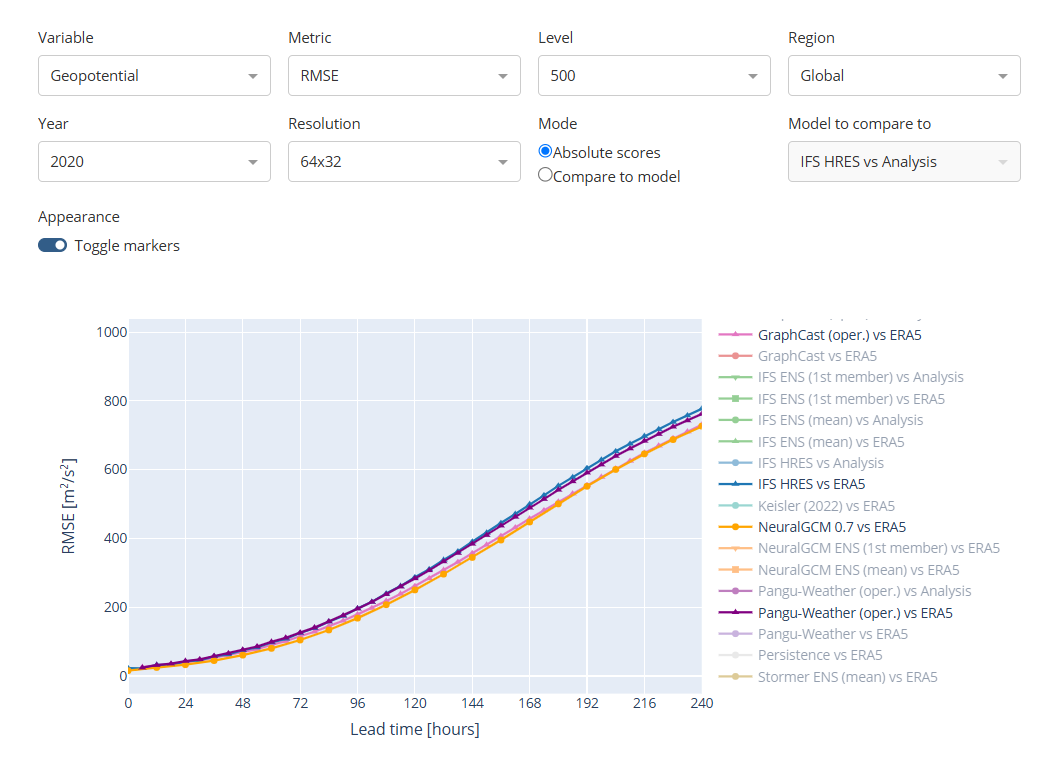

In [11]:
# @title Load Forecasts at 72 hour lead time

merged_datasets = joblib.load(drive_data_path+"aiwp_ml_setup_500geopotential_32x64_2020_leadtime72.pkl")
print(f"Merged_datasets size:{merged_datasets.shape} ")
print("First 5 rows of the merged_datasets:")
merged_datasets.head()

Merged_datasets size:(1499136, 8) 
First 5 rows of the merged_datasets:


,time,longitude,latitude,graphcast,pangu,neuralgcm,ifshres,area_weight
0,2020-01-04,0.0,-87.1875,49969.980469,49928.015625,50061.421875,50103.640625,0.049068
1,2020-01-04,0.0,-81.5625,50197.351562,50232.875000,50227.707031,50357.289062,0.146730
2,2020-01-04,0.0,-75.9375,50326.664062,50367.367188,50305.351562,50433.640625,0.242980
3,2020-01-04,0.0,-70.3125,50008.304688,50005.089844,49969.562500,50055.031250,0.336890
4,2020-01-04,0.0,-64.6875,49281.628906,49232.839844,49214.851562,49303.812500,0.427555


In [13]:
# @title Load ERA5

era5_dataset = joblib.load(drive_data_path+"era5_ml_setup_500geopotential_32x64_2020.pkl")
print(f"era5_dataset size:{era5_dataset.shape} ")
print("First 5 rows of the era5_dataset:")
era5_dataset.head()

era5_dataset size:(1556480, 5) 
First 5 rows of the era5_dataset:


,time,longitude,latitude,era5,area_weight
0,2020-01-01,0.0,-87.1875,49846.941406,0.049068
1,2020-01-01,0.0,-81.5625,50196.523438,0.146730
2,2020-01-01,0.0,-75.9375,50391.101562,0.242980
3,2020-01-01,0.0,-70.3125,49667.398438,0.336890
4,2020-01-01,0.0,-64.6875,49277.945312,0.427555


In [14]:
# @title Load ERA5 Climatology
era5_clim_dataset = joblib.load(drive_data_path+"era5_clim_ml_setup_500geopotential_32x64_1990_2019.pkl").drop(columns=["area_weight"])
print(f"era5_clim_dataset size:{era5_clim_dataset.shape} ")
print("First 5 rows of the era5_clim_dataset:")
era5_clim_dataset.head()

era5_clim_dataset size:(1499136, 5) 
First 5 rows of the era5_clim_dataset:


,hour,dayofyear,longitude,latitude,era5_clim
0,0,1,0.0,-87.1875,50254.402344
1,0,1,0.0,-81.5625,50291.894531
2,0,1,0.0,-75.9375,50371.437500
3,0,1,0.0,-70.3125,50221.105469
4,0,1,0.0,-64.6875,50185.886719


In [15]:
# @title Merge ERA5 + Climatology

# Add 'dayofyear' and 'hour' columns to era5_dataset for merging with climatology
era5_dataset['dayofyear'] = era5_dataset['time'].dt.dayofyear
era5_dataset['hour'] = era5_dataset['time'].dt.hour

# Merge era5_dataset with the processed climatology DataFrame
era5_dataset_with_clim = era5_dataset.merge(
    era5_clim_dataset[['dayofyear', 'hour', 'longitude', 'latitude', 'era5_clim']],
    on=['dayofyear', 'hour', 'longitude', 'latitude'],
    how='left'
)

print(f"Shape of era5_dataset_with_clim: {era5_dataset_with_clim.shape}")
print("First 5 rows of the aligned dataset:")
print(era5_dataset_with_clim.head())

Shape of era5_dataset_with_clim: (1556480, 8)
First 5 rows of the aligned dataset:
        time  longitude  latitude          era5  area_weight  dayofyear  hour  \
0 2020-01-01        0.0  -87.1875  49846.941406     0.049068          1     0   
1 2020-01-01        0.0  -81.5625  50196.523438     0.146730          1     0   
2 2020-01-01        0.0  -75.9375  50391.101562     0.242980          1     0   
3 2020-01-01        0.0  -70.3125  49667.398438     0.336890          1     0   
4 2020-01-01        0.0  -64.6875  49277.945312     0.427555          1     0   

      era5_clim  
0  50254.402344  
1  50291.894531  
2  50371.437500  
3  50221.105469  
4  50185.886719  


In [16]:
# @title Merge Forecasts and ERA5 + Climatology

merged_datasets = merged_datasets.rename(columns={col: col + "_lt72" for col in merged_datasets.columns if col not in ["time", "longitude", "latitude"]})
df = era5_dataset_with_clim.merge(merged_datasets, on=["time", "longitude", "latitude"], how="outer")

print(f"Dataframe size: {df.shape}")
print("First 5 rows od the merged dataset:")
df.head()

Dataframe size: (1556480, 13)
First 5 rows od the merged dataset:


,time,longitude,latitude,era5,area_weight,dayofyear,hour,era5_clim,graphcast_lt72,pangu_lt72,neuralgcm_lt72,ifshres_lt72,area_weight_lt72
0,2020-01-01,0.0,-87.1875,49846.941406,0.049068,1,0,50254.402344,NaN,NaN,NaN,NaN,NaN
1,2020-01-01,0.0,-81.5625,50196.523438,0.146730,1,0,50291.894531,NaN,NaN,NaN,NaN,NaN
2,2020-01-01,0.0,-75.9375,50391.101562,0.242980,1,0,50371.437500,NaN,NaN,NaN,NaN,NaN
3,2020-01-01,0.0,-70.3125,49667.398438,0.336890,1,0,50221.105469,NaN,NaN,NaN,NaN,NaN
4,2020-01-01,0.0,-64.6875,49277.945312,0.427555,1,0,50185.886719,NaN,NaN,NaN,NaN,NaN


## Calculate RMSE to compare to values on [WB2 website](https://sites.research.google/weatherbench/deterministic-scores/)

**Models:**
 * GraphCast(oper) vs ERA5 : **RMSE= 115.2911**
 * IFS HRES vs ERA5 : **RMSE = 124.8948**
 * NeuralGCM 0.7 vs ERA5 : **RMSE = 104.454**
 * Pangu-Weather (oper.) vs ERA5 : **RMSE = 125.9085**

In [18]:
graphcast_rmse = np.sqrt(((df["era5"]-df["graphcast_lt72"])**2 * df["area_weight"]).mean() / df["area_weight"].mean())
print(f"GraphCast RMSE: {graphcast_rmse:.2f}")

ifshres_rmse = np.sqrt(((df["era5"]-df["ifshres_lt72"])**2 * df["area_weight"]).mean() / df["area_weight"].mean())
print(f"IFS HRES RMSE: {ifshres_rmse:.2f}")

neuralgcm_rmse = np.sqrt(((df["era5"]-df["neuralgcm_lt72"])**2 * df["area_weight"]).mean() / df["area_weight"].mean())
print(f"NeuralGCM RMSE: {neuralgcm_rmse:.2f}")

pangu_rmse = np.sqrt(((df["era5"]-df["pangu_lt72"])**2 * df["area_weight"]).mean() / df["area_weight"].mean())
print(f"Pangu-Weather RMSE: {pangu_rmse:.2f}")

GraphCast RMSE: 115.16
IFS HRES RMSE: 124.89
NeuralGCM RMSE: 104.45
Pangu-Weather RMSE: 125.91


Do they equal RMSE? Yes they do! ✅

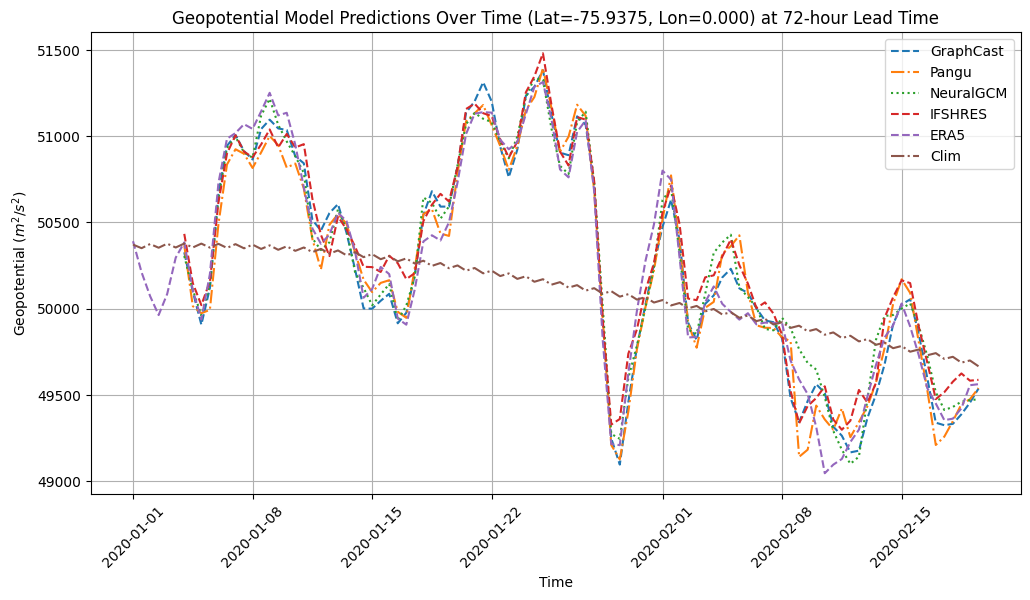

In [19]:

# @title Plot each model’s prediction over time for grid point "latitude == -75.9375 and longitude == 0.000"

df_filtered = df.query("latitude == -75.9375 and longitude == 0.000").iloc[:100]


plt.figure(figsize=(12, 6))
plt.plot(df_filtered["time"], df_filtered["graphcast_lt72"], label="GraphCast", linestyle="--")
plt.plot(df_filtered["time"], df_filtered["pangu_lt72"], label="Pangu", linestyle="-.")
plt.plot(df_filtered["time"], df_filtered["neuralgcm_lt72"], label="NeuralGCM", linestyle=":")
plt.plot(df_filtered["time"], df_filtered["ifshres_lt72"], label="IFSHRES", linestyle="--")
plt.plot(df_filtered["time"], df_filtered["era5"], label="ERA5", linestyle="dashed")
plt.plot(df_filtered["time"], df_filtered["era5_clim"], label="Clim", linestyle="dashdot")


# Formatting
plt.xlabel("Time")
plt.ylabel("Geopotential ($m^2/s^2$)")
plt.title("Geopotential Model Predictions Over Time (Lat=-75.9375, Lon=0.000) at 72-hour Lead Time")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.savefig(drive_plots_path+'Model_Predictions_Over_Time_(Lat=-75.9375, Lon=0.000)_100time.pdf', dpi=300, bbox_inches="tight")

plt.show()


**Remark** ✅

From the plot above we can confirm that the timeseries data for both ERA5 and models' forecasts are aligned as required during training.

# Proceed with Loading the data for all the leadtimes.

In [20]:
# @title Load forecasts & ERA5 truth

# This section loads the preprocessed data for machine learning setup.
# Ensure the data files are available in the specified path.

lead_times=[24, 48, 72, 96, 120, 144, 168, 192, 216, 240]

for lead_time in lead_times:
    print(lead_time)
    df_aiwp = pd.read_pickle(drive_data_path + f"aiwp_ml_setup_500geopotential_32x64_2020_leadtime{lead_time}.pkl").drop(columns=["area_weight"])
    df_aiwp_m = df
    df_aiwp = df_aiwp.rename(columns={col: col + "_lt" + str(lead_time) for col in df_aiwp.columns if col not in ["time", "longitude", "latitude"]})
    if lead_time == 24:
       df_aiwp_full = df_aiwp
    else:
       df_aiwp_full = df_aiwp_full.merge(df_aiwp, on=["time", "longitude", "latitude"], how="outer")

print(f"Shape of df_aiwp_full :{df_aiwp_full.shape}")

24
48
72
96
120
144
168
192
216
240
Shape of df_aiwp_full :(1536000, 43)


In [21]:
# @title Merge ERA5 + Climatology and Forecasts Across all lead times

# This section merges the ERA5 data with the AIWP forecasts across all lead times.
# Ensure that the merge is done on the correct columns to avoid data loss.
full_df = era5_dataset_with_clim.merge(df_aiwp_full, on=["time", "longitude", "latitude"], how="outer")
print(full_df.shape)
full_df.head()

(1556480, 48)


,time,longitude,latitude,era5,area_weight,dayofyear,hour,era5_clim,graphcast_lt24,pangu_lt24,...,neuralgcm_lt192,ifshres_lt192,graphcast_lt216,pangu_lt216,neuralgcm_lt216,ifshres_lt216,graphcast_lt240,pangu_lt240,neuralgcm_lt240,ifshres_lt240
0,2020-01-01,0.0,-87.1875,49846.941406,0.049068,1,0,50254.402344,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01,0.0,-81.5625,50196.523438,0.146730,1,0,50291.894531,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01,0.0,-75.9375,50391.101562,0.242980,1,0,50371.437500,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-01,0.0,-70.3125,49667.398438,0.336890,1,0,50221.105469,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-01,0.0,-64.6875,49277.945312,0.427555,1,0,50185.886719,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# @title Filter for subset of data for each lead time

# This section filters the data for each lead time to create a subset for analysis.
# The function `data_per_lead_time` filters the DataFrame based on the lead time and returns relevant columns.
def data_per_lead_time(df: pd.DataFrame, lead_time: int) -> pd.DataFrame:
    """
    Filters the DataFrame for a specific lead time and returns relevant columns.

    Args:
        df: The input DataFrame containing merged forecast and ERA5 data.
        lead_time: The lead time in hours to filter for.

    Returns:
        A filtered DataFrame containing data for the specified lead time
        with relevant columns (time, latitude, longitude, era5, area_weight,
        and model forecasts for the given lead time).
    """
    valid_time_lower = df['time'][0] + timedelta(days=int(lead_time / 24))
    valid_time_upper = valid_time_lower + relativedelta(years=1)
    df_filtered = df[(df['time'] > valid_time_lower) & (df['time'] < valid_time_upper)]
    return df_filtered[['time', 'latitude', 'longitude', "era5","era5_clim", "area_weight",
                        f'graphcast_lt{lead_time}',
                        f'pangu_lt{lead_time}',
                        f'neuralgcm_lt{lead_time}',
                        f'ifshres_lt{lead_time}'
                        ]]

In [23]:
# @title Check for NaN values in each lead time subset

# This section checks for NaN values in the data for each lead time subset.
for lead_time in lead_times:
    print(f"==== {lead_time}-hour Lead Time ====")
    print(data_per_lead_time(full_df,lead_time).isna().sum())

==== 24-hour Lead Time ====
time              0
latitude          0
longitude         0
era5              0
era5_clim         0
area_weight       0
graphcast_lt24    0
pangu_lt24        0
neuralgcm_lt24    0
ifshres_lt24      0
dtype: int64
==== 48-hour Lead Time ====
time              0
latitude          0
longitude         0
era5              0
era5_clim         0
area_weight       0
graphcast_lt48    0
pangu_lt48        0
neuralgcm_lt48    0
ifshres_lt48      0
dtype: int64
==== 72-hour Lead Time ====
time              0
latitude          0
longitude         0
era5              0
era5_clim         0
area_weight       0
graphcast_lt72    0
pangu_lt72        0
neuralgcm_lt72    0
ifshres_lt72      0
dtype: int64
==== 96-hour Lead Time ====
time              0
latitude          0
longitude         0
era5              0
era5_clim         0
area_weight       0
graphcast_lt96    0
pangu_lt96        0
neuralgcm_lt96    0
ifshres_lt96      0
dtype: int64
==== 120-hour Lead Time ====
time   

<a name="methodology"></a>
# Methodology

To enhance forecast accuracy beyond individual numerical, AI and hybrid weather prediction models, we propose a supervised learning ensemble strategy termed **PiggyCast** (a portmanteau of the words **piggy**back and fore**cast**).

**Piggyback** here means "to use something that already exists or has already been done successfully to do something else quickly or effectively".

This approach uses gradient-boosted decision trees, implemented via the XGBoost algorithm, to learn a mapping from ensemble forecasts and geographic coordinates to observed geopotential at 500 hPa.

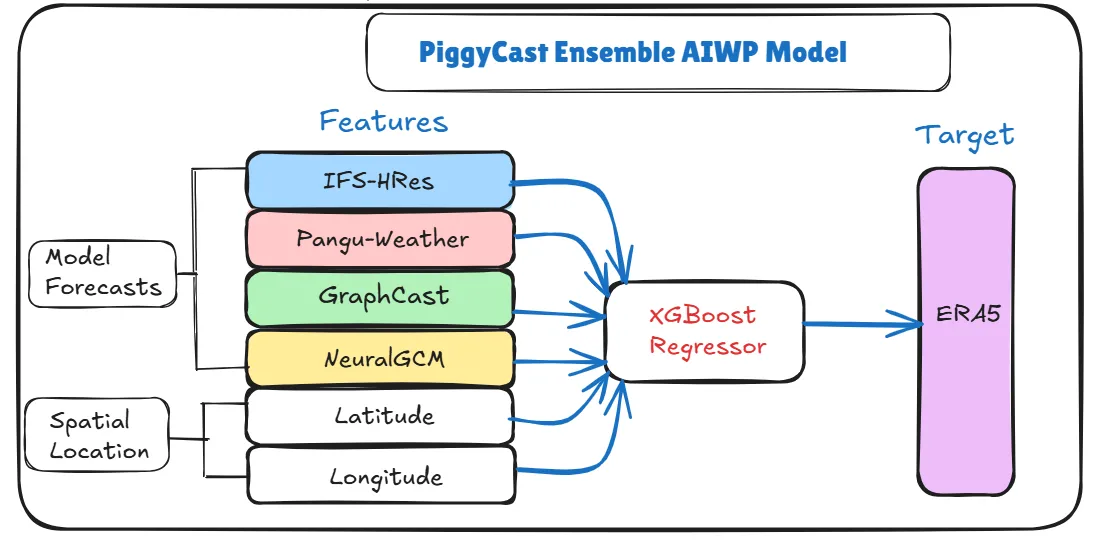

## XGBoost Regressor

XGBoost (**Extreme Gradient Boosting**) is a scalable and efficient implementation of gradient boosting machines, introduced by Chen in 2016 ([xgboost paper](https://arxiv.org/abs/1603.02754)). The model constructs an ensemble of regression trees in an additive manner, where each new tree is trained to correct the residual errors of the previous trees.

A key innovation of XGBoost lies in its **regularised objective function** and the use of **second-order Taylor expansion**, which contribute substantially to both its predictive performance and computational efficiency.

In this tutorial, we choose XGBoost as the regressor due to several advantages particularly relevant to weather and climate data analysis:

* **Ability to model complex non-linear relationships** — Weather data often involve highly non-linear dependencies between variables (e.g., humidity, temperature, pressure). XGBoost’s tree-based structure effectively captures these patterns.

* **Scalability to high-dimensional data** — Weather datasets can include a large number of features (temporal, spatial, derived indices). XGBoost is designed to handle such high-dimensional input efficiently.

* **Computational efficiency** — The library is optimized for parallelization and supports GPU acceleration, which is especially useful for large-scale weather prediction tasks.

* **Built-in regularization** — L1 and L2 regularization help reduce overfitting, which is critical when modeling noisy and uncertain data such as meteorological measurements.

* **Robustness and proven track record** — XGBoost has consistently delivered state-of-the-art performance across diverse regression and forecasting tasks, making it a reliable baseline and benchmark model.

### Learning Objective Function

The learning objective in XGBoost consists of a differentiable loss function that measures the model's fit and a regularisation term that penalises model complexity:


Let $f^{(i)}_{t+\tau}(\mathbf{x})$ denote the forecasted geopotential height at spatial location $\mathbf{x}$ and lead time $\tau$ hours by model $i \in \{\texttt{GraphCast}, \texttt{Pangu}, \texttt{NeuralGCM}, \texttt{IFS HRES}\}$.

The feature vector for each instance is defined as:

\begin{equation}
    \mathbf{x}_{\text{input}} = \left[ f^{(\texttt{GraphCast})}_{t+\tau}(\mathbf{x}), f^{(\texttt{Pangu})}_{t+\tau}(\mathbf{x}), f^{(\texttt{NeuralGCM})}_{t+\tau}(\mathbf{x}), f^{(\texttt{IFS HRES})}_{t+\tau}(\mathbf{x}), \text{lon}(\mathbf{x}), \text{lat}(\mathbf{x}) \right],
\end{equation}
with the target variable:
\begin{equation}
    y = f^{(\texttt{ERA5})}_{t+\tau}(\mathbf{x}),
\end{equation}
where $f^{(\texttt{ERA5})}_{t+\tau}$ is the reanalysis ground truth from ERA5, and lon($\mathbf{x}$), lat($\mathbf{x}$) denote the spatial coordinates.

The **loss function** around $ \hat{y}_i^{(t-1)} $ (prediction from the ensemble up to iteration $t-1 $):

\begin{equation}
\mathcal{L}^{(t)} \approx \sum_{i=1}^{n} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t),
\end{equation}

where $ g_i = \partial_{\hat{y}^{(t-1)}} l(y_i, \hat{y}_i^{(t-1)}) $ is the first-order gradient, and $ h_i = \partial^2_{\hat{y}^{(t-1)}} l(y_i, \hat{y}_i^{(t-1)}) $ is the second-order derivative (Hessian).

This use of both gradient and curvature information allows XGBoost to perform more accurate updates than methods relying on first-order approximations alone.

For a video explanation of XGBoost Regressor refer to one below:

[![IMAGE ALT TEXT HERE](https://img.youtube.com/vi/OtD8wVaFm6E/0.jpg)](https://www.youtube.com/watch?v=OtD8wVaFm6E)

## Time Series Cross-Validation

Time series data violates the standard assumption of independently and identically distributed (i.i.d.) samples due to its inherent temporal dependencies. As such, conventional cross-validation approaches like random shuffling are unsuitable because they introduce look-ahead bias and data leakage. Instead, time series-aware cross-validation techniques must be used, which honour the chronological order of observations.

We employ a rolling-origin evaluation strategy known as $\texttt{TimeSeriesSplit}$, which partitions the data into a sequence of non-overlapping training and test sets, with the test set always following the training set in time.
Formally, for a given univariate time series $\{y_t\}_{t=1}^T$, and $K$ folds, the $k$-th training set is defined as:

\begin{equation}
    \mathcal{D}^{(k)}_{\text{train}} = \{y_1, y_2, \ldots, y_{t_k}\}, \quad
\mathcal{D}^{(k)}_{\text{test}} = \{y_{t_k + g + 1}, \ldots, y_{t_k + g + h}\}
\end{equation}

where $g$ is the size of the gap between training and test sets to reduce temporal autocorrelation, and $h$ is the horizon or length of the test window. This approach avoids information leakage while maintaining the temporal structure of the data, ensuring the test window always follows the training window, with a temporal buffer to mitigate short-term autocorrelations and hence a robust assessment of model generalisation to future data.


In our implementation, we use 10-fold cross-validation $\texttt{TimeSeriesSplit}$, with each fold comprising:
  * $\textbf{Training set:}$ $64 \times 32 \times 2 \times 60$ time steps (60 days of training)
  * $\textbf{Test set:}$ $64 \times 32 \times 2 \times 30$ time steps (30 days of testing)
  * $\textbf{Gap:}$ $64 \times 32 \times 2 \times 5$ time steps (5 days as autocorrelation gap)

where $64\times32\times2$ are the longitude and latitude geopotential values evaluated twice in a day (noon and midnight).

In [24]:
# @title Plot the train-test splits for each Fold

# This section visualizes the train-test splits for each fold in the cross-validation process.
def cross_validation_plot(df: pd.DataFrame, cv: TimeSeriesSplit, lead_time: int):
    """
    Plots the train-test splits for each fold in the TimeSeriesSplit cross-validation.

    Args:
        df: The input DataFrame containing the time series data.
        cv: The TimeSeriesSplit cross-validation object.
        lead_time: The lead time in hours for the plot title.
    """
    # Extract datetime info using the filtered df
    time_index = df["time"].reset_index(drop=True)

    # Store train/test index lists
    train_indices_list = []
    test_indices_list = []
    for train_index, test_index in cv.split(X):
        train_indices_list.append(train_index)
        test_indices_list.append(test_index)

    # Create the plot
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    fig, ax = plt.subplots(figsize=(12, 10))

    # Plot each fold
    for i in range(10):
        # Convert indices to datetime for x-axis
        train_times = time_index.iloc[train_indices_list[i]]
        test_times = time_index.iloc[test_indices_list[i]]

        ax.plot(train_times, [i + 1] * len(train_times), 'bo', label='Train' if i == 0 else "", markersize=5)
        ax.plot(test_times, [i + 1] * len(test_times), 'ro', label='Test' if i == 0 else "", markersize=5)
        ax.axhline(y=i + 1.5, color='lightgray', linestyle='--')

    # Format x-axis as months
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

    # Labels and title
    ax.set_xlabel('Month')
    ax.set_ylabel('Fold')
    ax.set_yticks(range(1, 11))
    ax.set_yticklabels([f'Fold {i+1}' for i in range(10)])
    ax.set_title(f'Training, Gap and Testing Windows Across 10 Folds for {lead_time} hours lead time.')
    ax.legend(loc='upper right')

    # Improve layout and save
    plt.tight_layout()
    # plt.savefig(data_plot_path + f'Training_Testing_Folds_By_Month_{lead_time}.pdf',
    #             dpi=300, bbox_inches="tight")

    plt.show()

## Evaluation Metrics

1. **Area-weighted RMSE**

Let M1 and M2 represent the ERA5 value and a model spatial forecast, respectively, then

\begin{equation}
    \text{RMSE}(M_1, M_2) = \sqrt{ \frac{ \sum_{i=1}^{n} w_i \cdot (M_{1,i} - M_{2,i})^2 }{ \sum_{i=1}^{n} w_i} },
\end{equation}


where

$$w_i=w(\phi_i)=  \cos\left( \frac{\pi \cdot \phi_i}{180} \right)$$


is the area weight for grid point $i$ on latitude $\phi$, and $n$ is the number of grid points.

2. **Model Performance Across Lead Times**

We evaluate performance over nine lead times $\tau \in \{24, 48, 72, 96, 120, 144, 168, 192, 216, 240\}$ hours. For each fold and model, we compute the area-weighted RMSE, then average across folds:

\begin{equation}
   \text{RMSE}_{\text{avg}}^{(m, \tau)} = \frac{1}{K} \sum_{k=1}^K \text{RMSE}_{k}^{(m, \tau)},
\end{equation}

where $m$ is the model and $K=10$ is the number of folds.

In [25]:
# @title RMSE Comparison for each model and fold

# This section compares the RMSE of different models across each fold in the cross-validation process.
def train_and_evaluate(xgb, cv: TimeSeriesSplit, X: pd.DataFrame, y: pd.Series, area_weight: pd.Series, lead_time: int):
  """
  Trains an XGBoost model and evaluates its performance along with base models
  across cross-validation folds, calculating RMSE and generating SHAP values.

  Args:
      xgb: The XGBoost regressor object.
      cv: The TimeSeriesSplit cross-validation object.
      X: DataFrame of features.
      y: Series of target values (ERA5).
      area_weight: Series of area weights.
      lead_time: The lead time in hours.

  Returns:
      A tuple containing:
          - results: A dictionary storing RMSE for each model and fold.
          - shapley_values: A dictionary storing SHAP values for each fold.
  """
  # Create a dictionary to store the results for each fold
  results = {}
  shapley_values = {}

  for fold, (train_index, test_index) in enumerate(cv.split(X)):
      print(f"Fold {fold+1}:")
      fold_results = {}

      X_train, X_test = X.iloc[train_index], X.iloc[test_index]
      y_train, y_test = y.iloc[train_index], y.iloc[test_index]

      xgb.fit(X_train, y_train, sample_weight=area_weight.iloc[train_index])



      y_pred = xgb.predict(X_test)
      mse = mean_squared_error(y_test, y_pred)
      print(f"  mse: {mse}")

      area_weighted_rmse = np.sqrt(((y_test-y_pred)**2 * area_weight.iloc[test_index]).mean() / area_weight.iloc[test_index].mean())
      print(f"  PiggyCast: area weighted rmse: {area_weighted_rmse}")
      fold_results["PiggyCast"] = area_weighted_rmse

      for model in [f"graphcast_lt{lead_time}",
                    f"pangu_lt{lead_time}",
                    f"neuralgcm_lt{lead_time}",
                    f"ifshres_lt{lead_time}"]:
          area_weighted_rmse = np.sqrt(((y_test-X_test[model])**2 * area_weight.iloc[test_index]).mean() / area_weight.iloc[test_index].mean())
          print(f"  {model.split('_')[0]}: area weighted rmse: {area_weighted_rmse}")
          fold_results[model.split('_')[0]] = area_weighted_rmse

      results[fold+1] = fold_results

      explainer = shap.TreeExplainer(model=xgb)
      shapley_values_fold = explainer(X_train)
      shapley_values[fold+1] = shapley_values_fold


  return results, shapley_values

In [26]:
# @title RMSE Comparison for each model and fold

# This section compares the RMSE of different models across each fold in the cross-validation process.
def train_and_evaluate(xgb, cv,X,y, area_weight,lead_time):
  # Create a dictionary to store the results for each fold
  results = {}
  shapley_values = {}

  for fold, (train_index, test_index) in enumerate(cv.split(X)):
      print(f"Fold {fold+1}:")
      fold_results = {}

      X_train, X_test = X.iloc[train_index], X.iloc[test_index]
      y_train, y_test = y.iloc[train_index], y.iloc[test_index]

      xgb.fit(X_train, y_train, sample_weight=area_weight.iloc[train_index])



      y_pred = xgb.predict(X_test)
      mse = mean_squared_error(y_test, y_pred)
      print(f"  mse: {mse}")

      area_weighted_rmse = np.sqrt(((y_test-y_pred)**2 * area_weight.iloc[test_index]).mean() / area_weight.iloc[test_index].mean())
      print(f"  PiggyCast: area weighted rmse: {area_weighted_rmse}")
      fold_results["PiggyCast"] = area_weighted_rmse

      for model in [f"graphcast_lt{lead_time}",
                    f"pangu_lt{lead_time}",
                    f"neuralgcm_lt{lead_time}",
                    f"ifshres_lt{lead_time}"]:
          area_weighted_rmse = np.sqrt(((y_test-X_test[model])**2 * area_weight.iloc[test_index]).mean() / area_weight.iloc[test_index].mean())
          print(f"  {model.split('_')[0]}: area weighted rmse: {area_weighted_rmse}")
          fold_results[model.split('_')[0]] = area_weighted_rmse

      results[fold+1] = fold_results

      # Use shap.TreeExplainer for tree-based models
      explainer = shap.TreeExplainer(model=xgb)
      shapley_values_fold = explainer(X_train)
      shapley_values[fold+1] = shapley_values_fold


  return results, shapley_values

In [27]:
# @title Plot RMSE per fold and Model

# This section plots the RMSE for each fold and model, allowing for a visual comparison of model performance.
def rmse_per_fold_plot(results: dict, lead_time: int):
  """
  Plots the RMSE for each model across all folds for a given lead time.

  Args:
      results: A dictionary containing RMSE values for each model and fold.
      lead_time: The lead time in hours for the plot title.
  """
  plt.rcParams['axes.titlesize'] = 16
  plt.rcParams['axes.labelsize'] = 14
  plt.rcParams['xtick.labelsize'] = 14
  plt.rcParams['ytick.labelsize'] = 14
  plt.rcParams['legend.fontsize'] = 14
  fig, ax = plt.subplots(figsize=(8, 6))

  for model in results[1].keys():  # Iterate through all model names
      rmse_values = [results[fold][model] for fold in results]
      fold_numbers = list(results.keys())
      ax.plot(fold_numbers, rmse_values, label=model, marker='o')

  ax.set_xlabel('Fold')
  ax.set_ylabel('RMSE ($m^2/s^2$)')
  ax.set_title(f'Geopotential RMSE for Each Fold and Model at {lead_time} hours lead time.')
  ax.legend(loc="upper right")
  plt.grid(True)
  # plt.savefig(data_plot_path + f'RMSE_for_Each_Fold_and_Model_{lead_time}.pdf',
  #             dpi=300, bbox_inches="tight")


  plt.show()

##Feature Attribution: SHAP (SHapley Additive exPlanations) Values
To gain insight into the model’s decision-making process, we consider SHAP **(SHapley Additive exPlanations)** values.

Given the trained model $f$ and input $x$, the SHAP value $\phi_j$ for feature j represents the marginal contribution of that feature:

\begin{equation}
f(\mathbf{x}) = \phi_0 + \sum_{j=1}^{M} \phi_j,    
\end{equation}

where $\phi_0$ is the base value (mean model output) and M is the number of input features.

These SHAP values provided both local and global insights into how different base model forecasts and geographic features contributed to PiggyCast’s output.


In [28]:
# @title Combined Shapely Values for Feature importance

# This section combines the Shapley values from all folds for each lead time into a single Explanation object.
def combined_shap_explanations_per_lead_time(shap_values_dict: dict) -> shap.Explanation:
    """
    Combines Shapley values from different folds into a single Explanation object.

    Args:
        shap_values_dict: A dictionary where keys are fold numbers and values
                          are shap.Explanation objects for each fold.

    Returns:
        A single shap.Explanation object containing combined Shapley values
        from all folds.
    """
    # Step 1: Collect all Explanation objects
    all_explanations = list(shap_values_dict.values())  # shap_values is your fold-wise dict

    # Step 2: Concatenate .values, .base_values, .data, etc.
    combined_values = np.concatenate([e.values for e in all_explanations], axis=0)
    combined_base_values = np.concatenate([e.base_values for e in all_explanations], axis=0)
    combined_data = np.concatenate([e.data for e in all_explanations], axis=0)

    # Step 3: Recreate the Explanation object
    combined_explanation = shap.Explanation(
        values=combined_values,
        base_values=combined_base_values,
        data=combined_data,
        feature_names=all_explanations[0].feature_names
    )
    return combined_explanation

<a name="results-and-discussion"></a>
# Results & Discussion

This section outlines our results and discusses the performance of the PiggyCast model, for geopotential at 500 hPa, against
the other weather prediction models.

## Training and Evaluation Loop (4 minutes on T4 TPU)

This section initializes the XGBoost regressor and performs cross-validation for each lead time.

We fit the XGBoost regressor using T4 Nvidia GPUs for accelerated training and testing for every fold, model and lead times. Here we track the performance of the XGBoost ensemble model using our coined model name **PiggyCast** against the performance of the other four models **(NeuralGCM, GraphCast, Pangu and IFS HRES)**.

Note that no hyperparameter tuning is done - we chose to stick with the XGBoost defaults since they are known to be a reasonable starting point. Tuning can yield even better results but we don't cover this in this tutorial.

Importantly, we incorporate spatial heterogeneity by applying area-based sample weights during training and evaluation, ensuring that larger grid areas have proportionally greater influence on the loss function.

The predictive performance is evaluated using an area-weighted RMSE metric.

In [31]:
# ================================================================
# @title 🌱 Start emissions tracking before training
# ================================================================
emissions_tracker.start()
print("🟢 Emissions tracking started. Training PiggyCast...")


🟢 Emissions tracking started. Training PiggyCast...


Lead time: 24
Shape of x :(1497088, 6)
Shape of y : (1497088,)


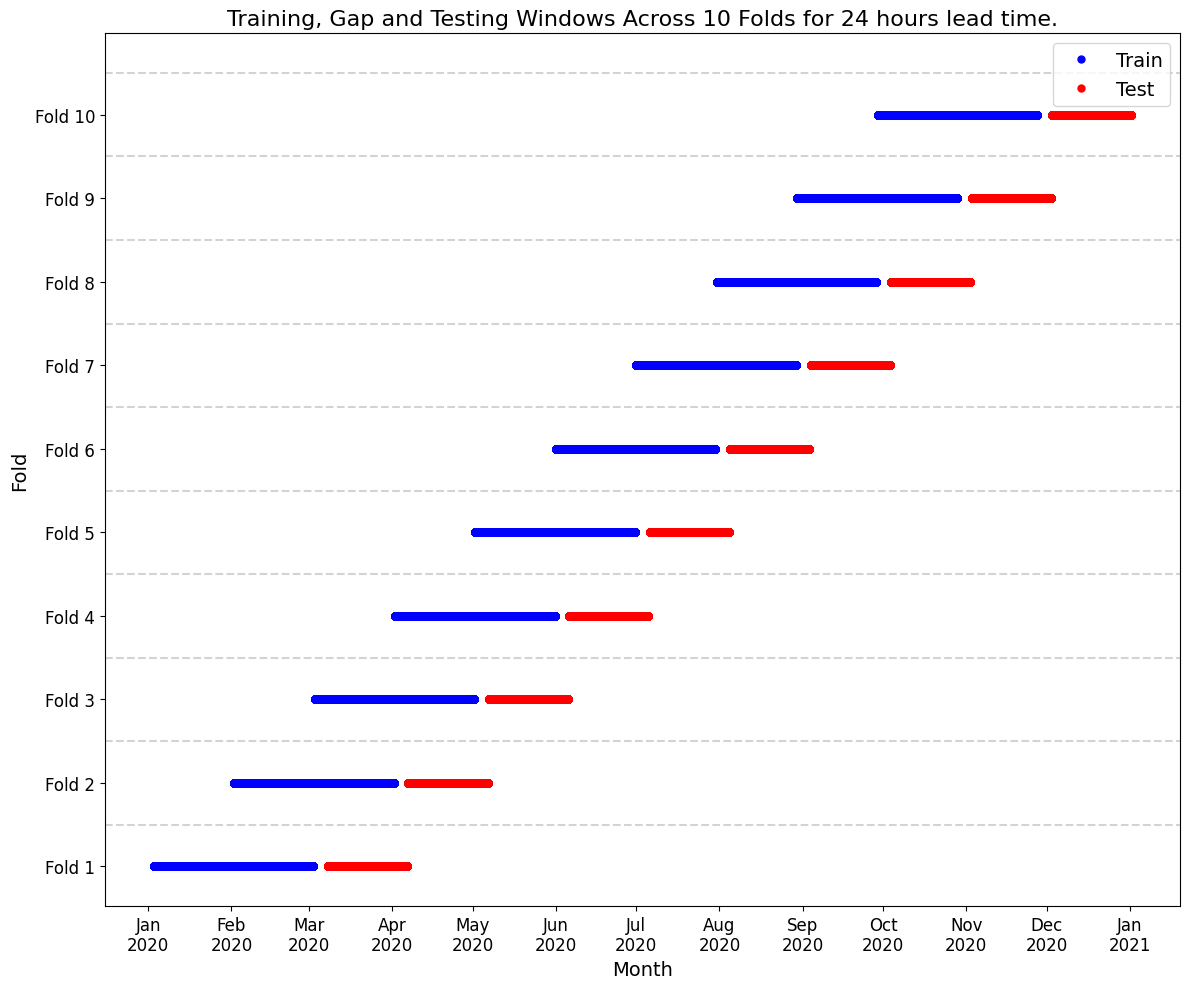

Fold 1:
  mse: 13414.962890625
  PiggyCast: area weighted rmse: 63.693080403483314
  graphcast: area weighted rmse: 41.40254878418716
  pangu: area weighted rmse: 45.47530433844694
  neuralgcm: area weighted rmse: 32.75386853518299
  ifshres: area weighted rmse: 44.02957276633646
Fold 2:
  mse: 5837.57470703125
  PiggyCast: area weighted rmse: 47.98610378263489
  graphcast: area weighted rmse: 41.2974180075092
  pangu: area weighted rmse: 44.202025786125155
  neuralgcm: area weighted rmse: 32.99595662092837
  ifshres: area weighted rmse: 41.984766958172806
Fold 3:
  mse: 3811.27734375
  PiggyCast: area weighted rmse: 44.11819929127061
  graphcast: area weighted rmse: 41.793244337180354
  pangu: area weighted rmse: 41.86942435086242
  neuralgcm: area weighted rmse: 32.284464080433736
  ifshres: area weighted rmse: 41.266132788237535
Fold 4:
  mse: 7843.0263671875
  PiggyCast: area weighted rmse: 59.59574953234368
  graphcast: area weighted rmse: 39.31747093435516
  pangu: area weighted 

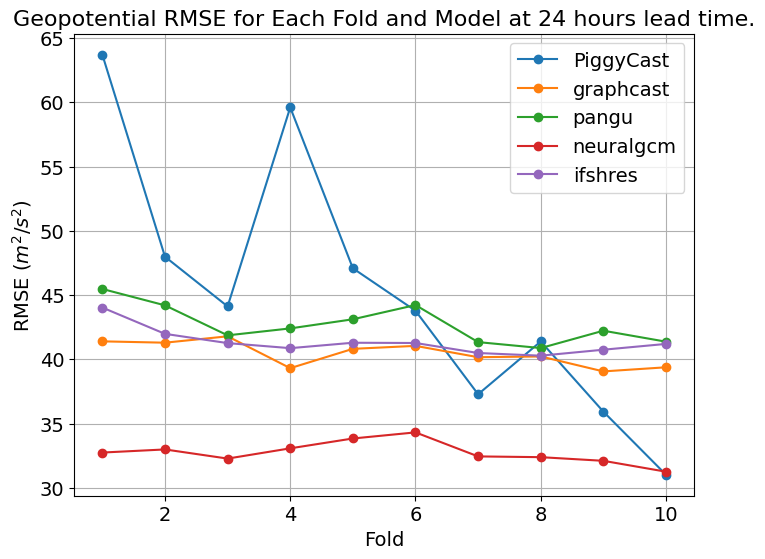

Lead time: 48
Shape of x :(1497088, 6)
Shape of y : (1497088,)


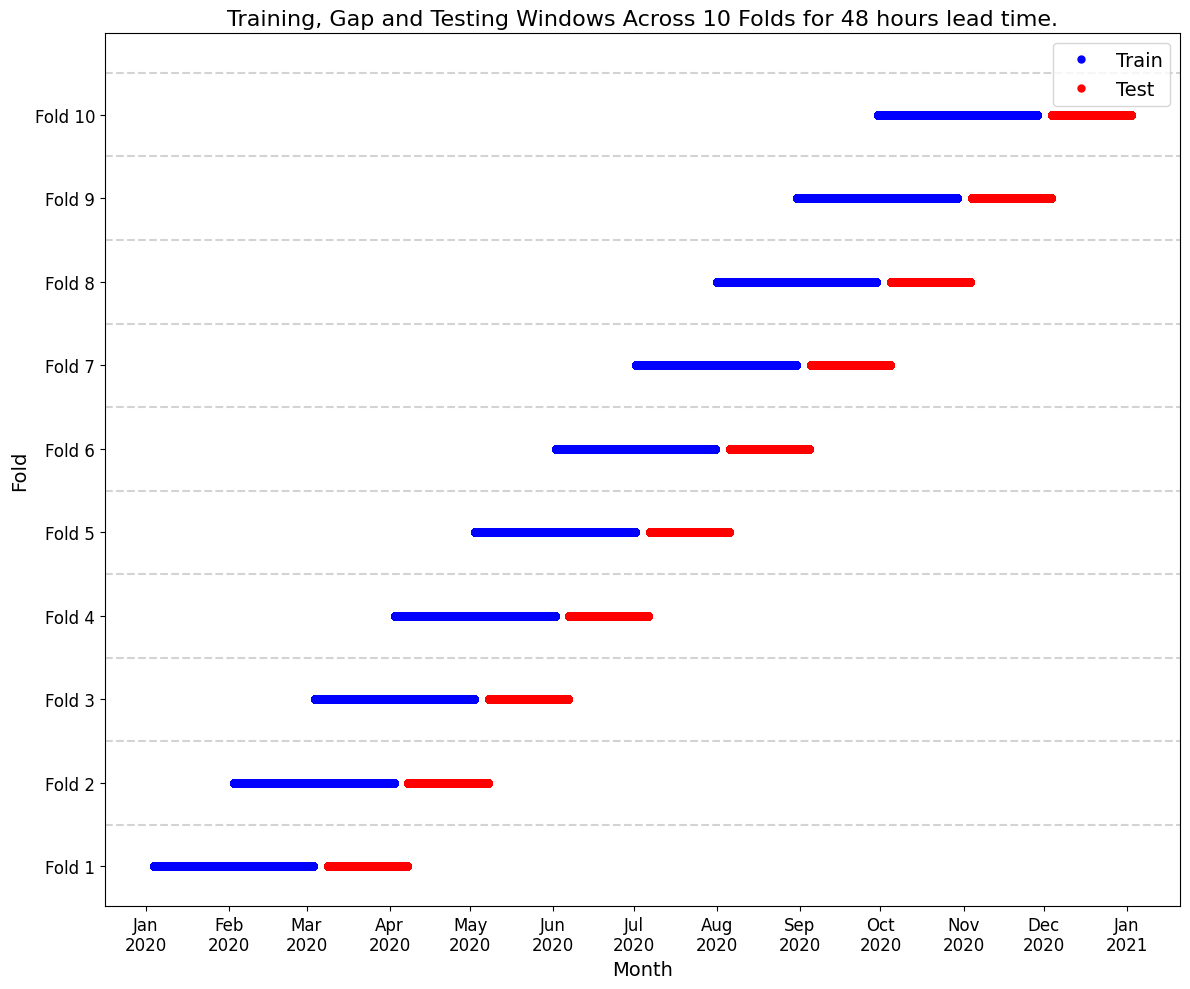

Fold 1:
  mse: 15209.0927734375
  PiggyCast: area weighted rmse: 76.76277746972184
  graphcast: area weighted rmse: 72.89521727913798
  pangu: area weighted rmse: 81.53557879205798
  neuralgcm: area weighted rmse: 61.32865112702906
  ifshres: area weighted rmse: 77.69317822238818
Fold 2:
  mse: 9210.8720703125
  PiggyCast: area weighted rmse: 66.86750469041097
  graphcast: area weighted rmse: 70.89595346008002
  pangu: area weighted rmse: 80.0969255422813
  neuralgcm: area weighted rmse: 62.04284877201307
  ifshres: area weighted rmse: 76.40121126092066
Fold 3:
  mse: 7203.16845703125
  PiggyCast: area weighted rmse: 64.48324208575639
  graphcast: area weighted rmse: 70.5749420055696
  pangu: area weighted rmse: 74.76480428843476
  neuralgcm: area weighted rmse: 61.50660557160111
  ifshres: area weighted rmse: 74.98039911101573
Fold 4:
  mse: 10929.08203125
  PiggyCast: area weighted rmse: 74.77433859172058
  graphcast: area weighted rmse: 67.91825353957019
  pangu: area weighted rmse:

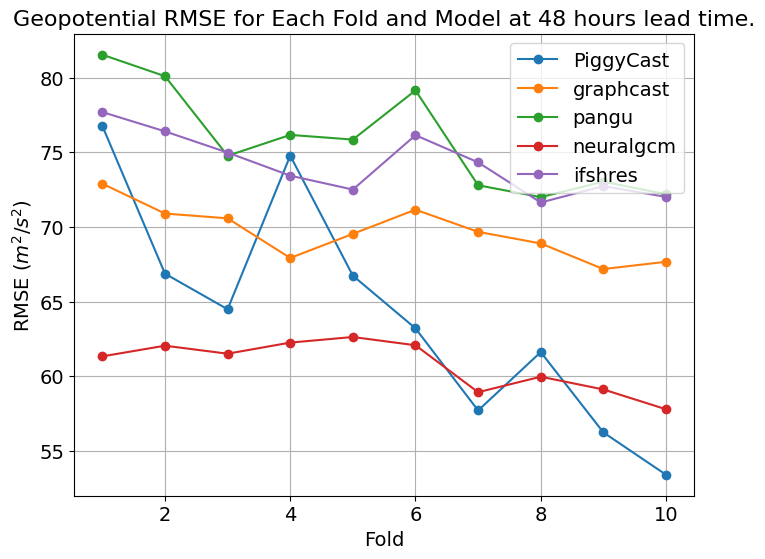

Lead time: 72
Shape of x :(1497088, 6)
Shape of y : (1497088,)


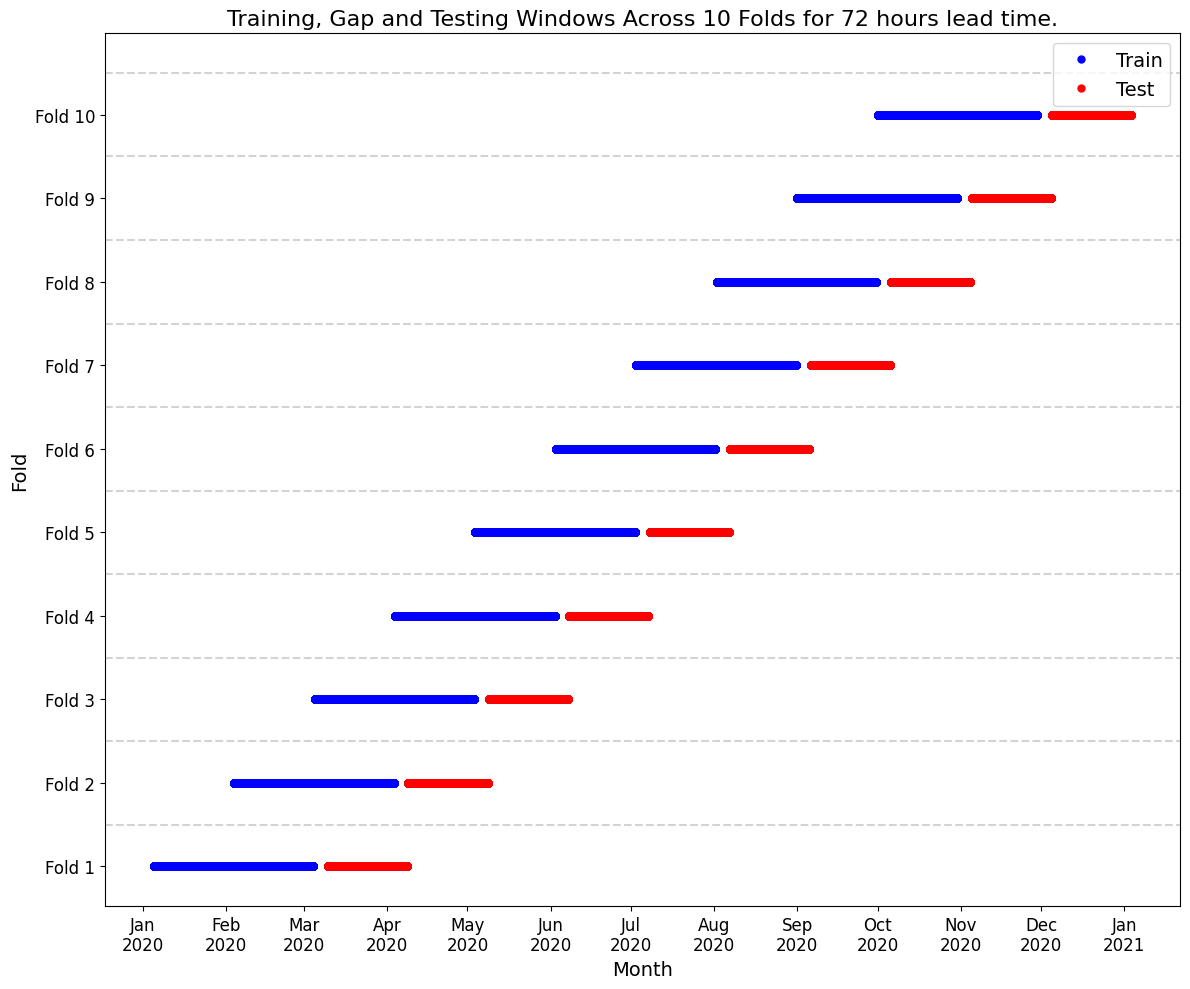

Fold 1:
  mse: 25877.22265625
  PiggyCast: area weighted rmse: 115.03192565675418
  graphcast: area weighted rmse: 122.85387708812033
  pangu: area weighted rmse: 135.08533958019098
  neuralgcm: area weighted rmse: 108.71967205337731
  ifshres: area weighted rmse: 131.52903243672063
Fold 2:
  mse: 20881.48046875
  PiggyCast: area weighted rmse: 107.9994745127202
  graphcast: area weighted rmse: 121.55502280923785
  pangu: area weighted rmse: 134.301915560045
  neuralgcm: area weighted rmse: 110.53258883735597
  ifshres: area weighted rmse: 130.6921929942073
Fold 3:
  mse: 16885.568359375
  PiggyCast: area weighted rmse: 102.35013330448703
  graphcast: area weighted rmse: 115.12777744553853
  pangu: area weighted rmse: 124.96075061143948
  neuralgcm: area weighted rmse: 106.80123183454789
  ifshres: area weighted rmse: 126.64768147865912
Fold 4:
  mse: 21867.5078125
  PiggyCast: area weighted rmse: 110.57140621198165
  graphcast: area weighted rmse: 113.60324813116003
  pangu: area weig

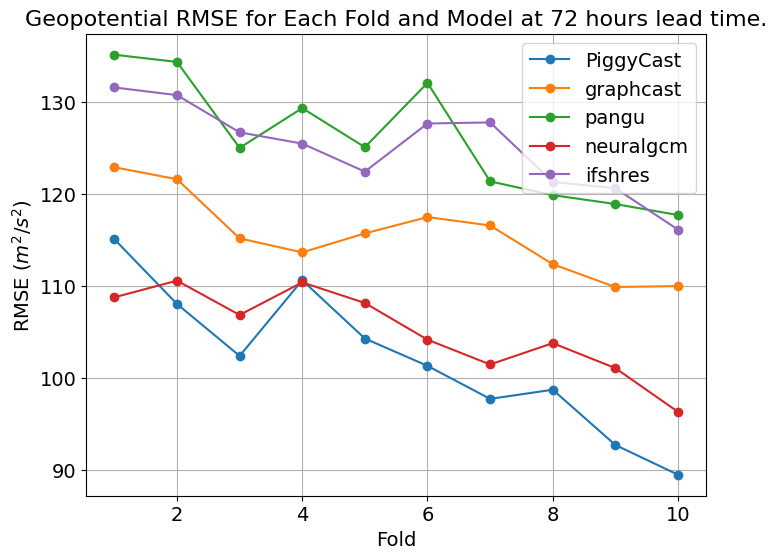

Lead time: 96
Shape of x :(1497088, 6)
Shape of y : (1497088,)


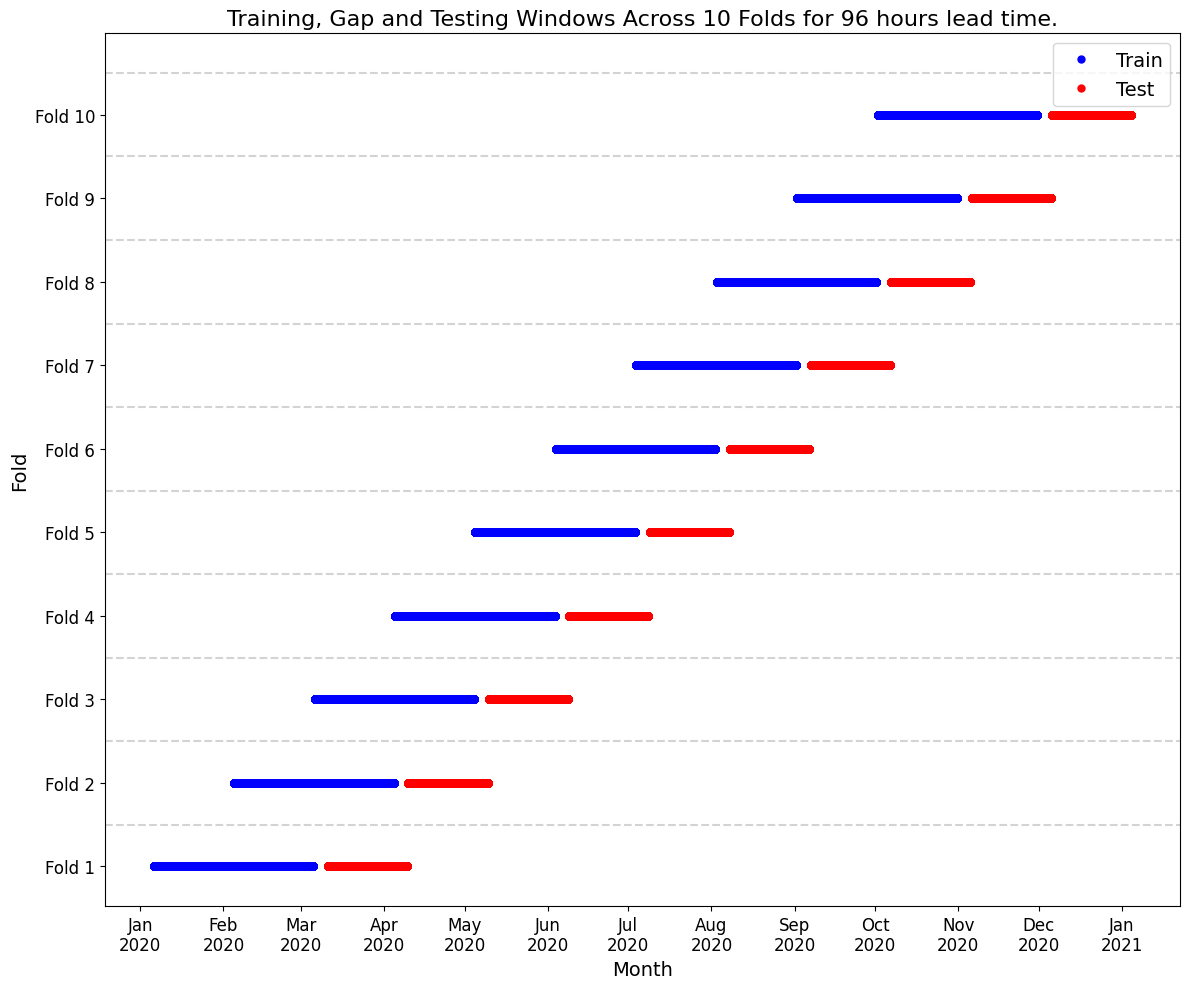

Fold 1:
  mse: 49030.41015625
  PiggyCast: area weighted rmse: 173.3933654454449
  graphcast: area weighted rmse: 195.20152988737848
  pangu: area weighted rmse: 214.2739069415602
  neuralgcm: area weighted rmse: 183.47832716814014
  ifshres: area weighted rmse: 211.0631693118561
Fold 2:
  mse: 49216.3828125
  PiggyCast: area weighted rmse: 173.20730639987448
  graphcast: area weighted rmse: 194.64755688125868
  pangu: area weighted rmse: 210.01758958971823
  neuralgcm: area weighted rmse: 182.68180403007085
  ifshres: area weighted rmse: 208.39683576970685
Fold 3:
  mse: 41151.58984375
  PiggyCast: area weighted rmse: 159.33845029265757
  graphcast: area weighted rmse: 176.69547419552768
  pangu: area weighted rmse: 193.9775290252984
  neuralgcm: area weighted rmse: 169.6390777359622
  ifshres: area weighted rmse: 196.72423677888227
Fold 4:
  mse: 49652.28515625
  PiggyCast: area weighted rmse: 167.75842205694278
  graphcast: area weighted rmse: 176.80927742788037
  pangu: area weight

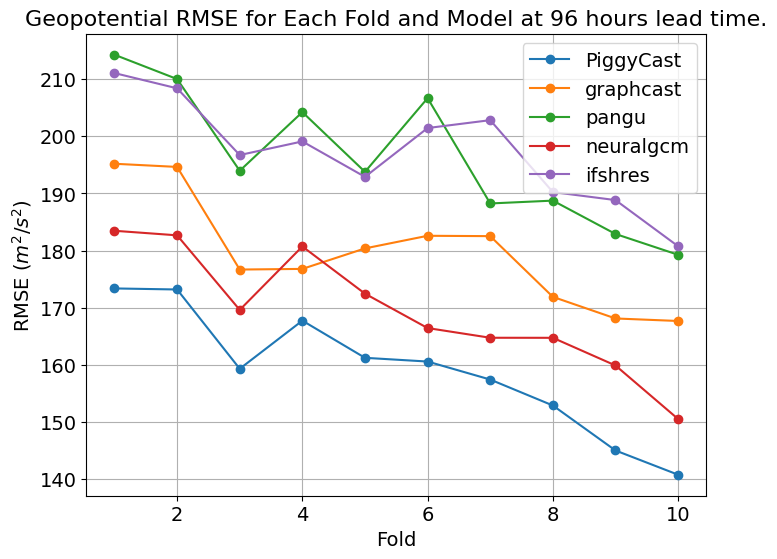

Lead time: 120
Shape of x :(1497088, 6)
Shape of y : (1497088,)


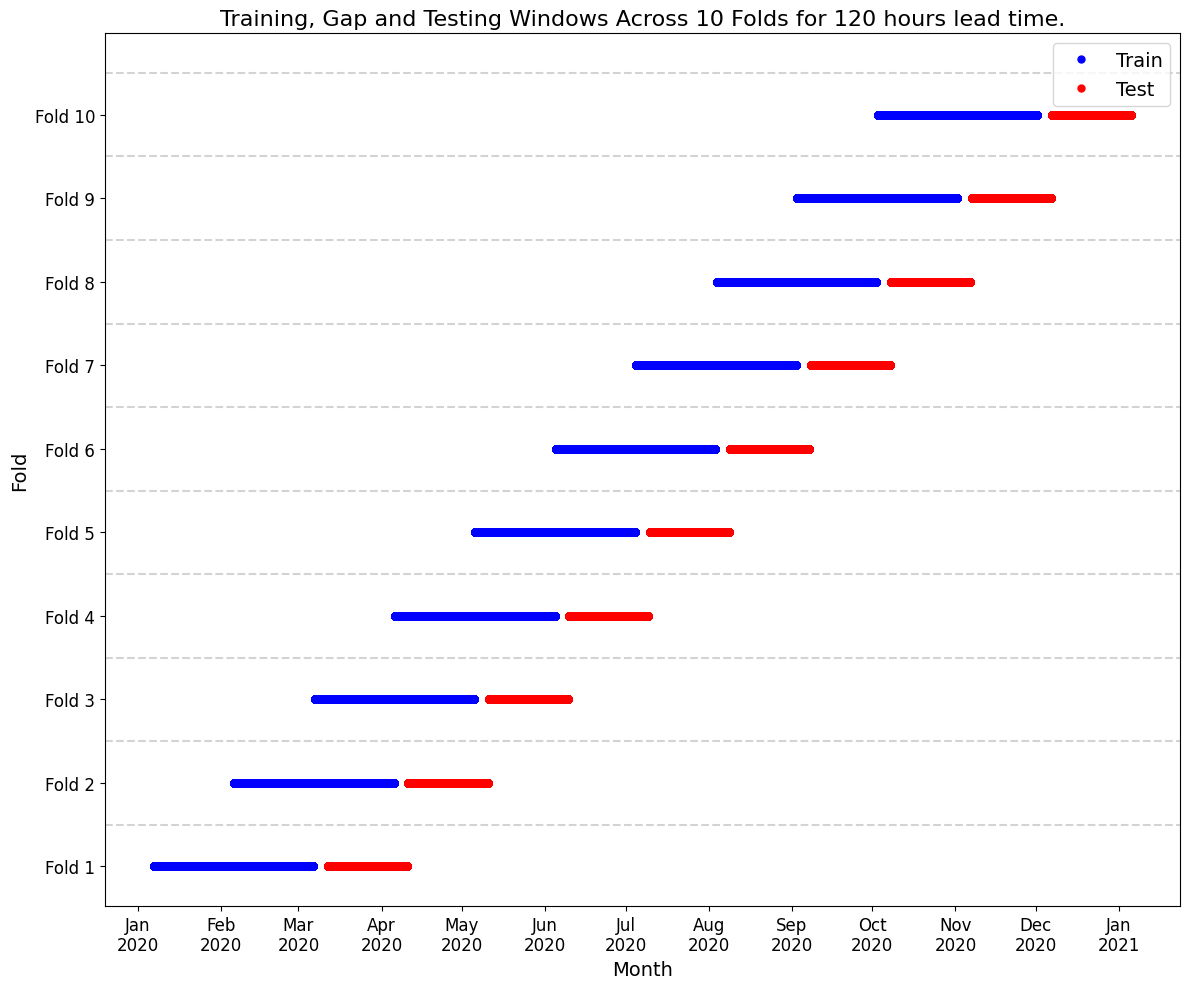

Fold 1:
  mse: 99350.328125
  PiggyCast: area weighted rmse: 256.9934900530293
  graphcast: area weighted rmse: 289.02530986166664
  pangu: area weighted rmse: 317.11599422643104
  neuralgcm: area weighted rmse: 279.53249851612685
  ifshres: area weighted rmse: 312.0320791214949
Fold 2:
  mse: 115796.2109375
  PiggyCast: area weighted rmse: 262.20523145638987
  graphcast: area weighted rmse: 286.07199267914655
  pangu: area weighted rmse: 304.75567864228253
  neuralgcm: area weighted rmse: 275.9779207899643
  ifshres: area weighted rmse: 313.67331244667685
Fold 3:
  mse: 96463.125
  PiggyCast: area weighted rmse: 237.08360775578984
  graphcast: area weighted rmse: 257.4964888728838
  pangu: area weighted rmse: 280.9105615258708
  neuralgcm: area weighted rmse: 251.97674444562148
  ifshres: area weighted rmse: 285.06761249662856
Fold 4:
  mse: 105545.890625
  PiggyCast: area weighted rmse: 243.88383603675504
  graphcast: area weighted rmse: 260.0811944089117
  pangu: area weighted rmse:

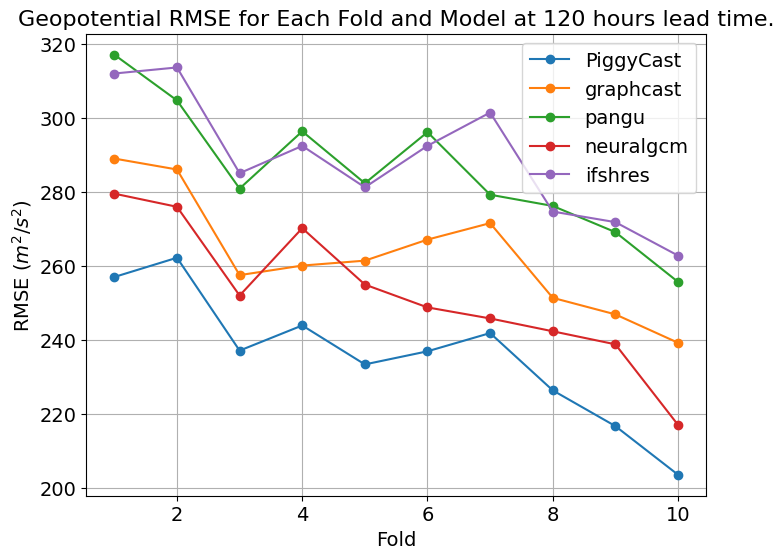

Lead time: 144
Shape of x :(1497088, 6)
Shape of y : (1497088,)


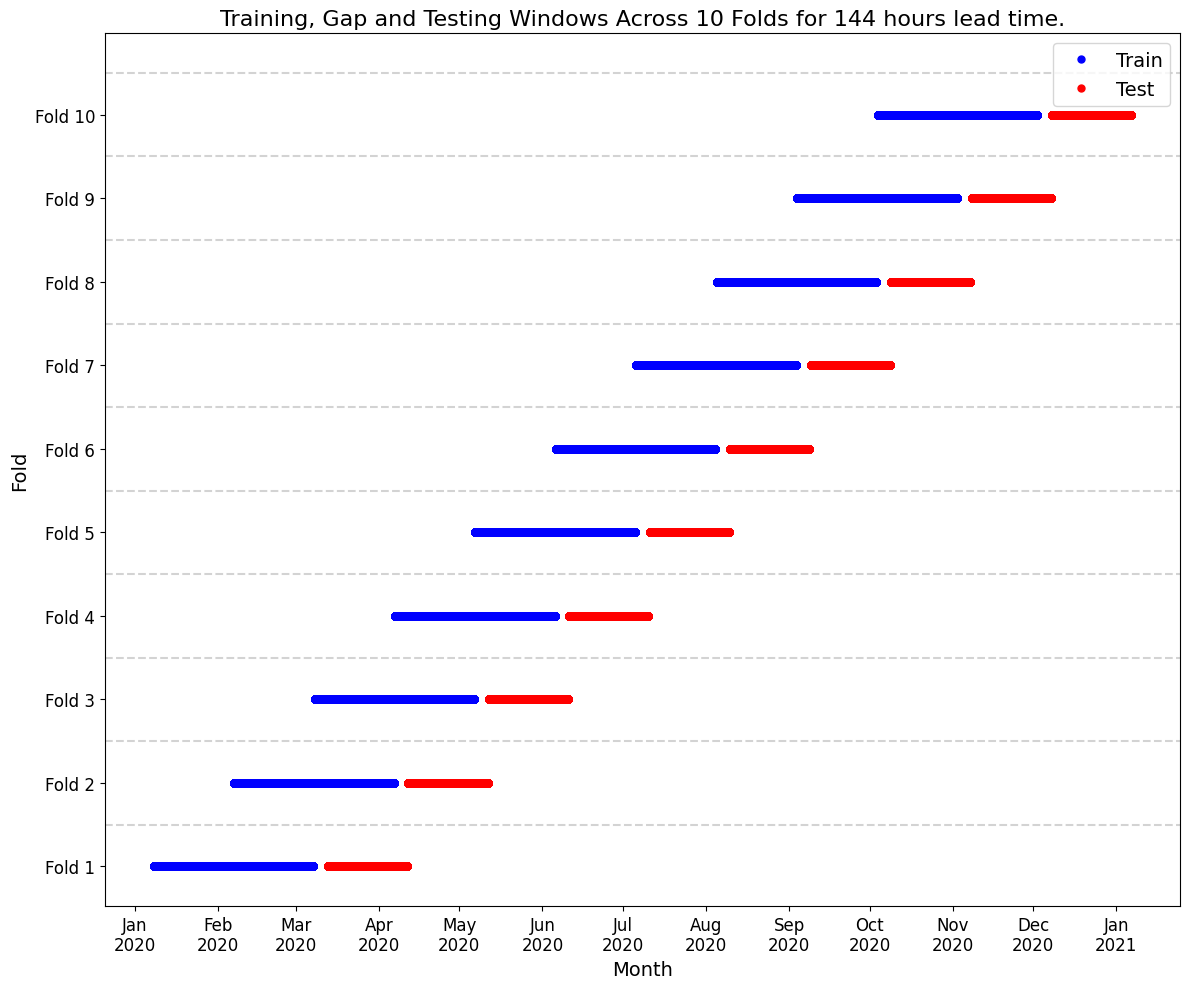

Fold 1:
  mse: 186383.4375
  PiggyCast: area weighted rmse: 354.99392875236487
  graphcast: area weighted rmse: 399.86372920955586
  pangu: area weighted rmse: 437.61787181657746
  neuralgcm: area weighted rmse: 394.0279406911589
  ifshres: area weighted rmse: 431.2164276194805
Fold 2:
  mse: 231560.953125
  PiggyCast: area weighted rmse: 365.24154654343346
  graphcast: area weighted rmse: 389.9872616428563
  pangu: area weighted rmse: 413.4022907262475
  neuralgcm: area weighted rmse: 377.58447976827415
  ifshres: area weighted rmse: 432.50340732619514
Fold 3:
  mse: 167832.0625
  PiggyCast: area weighted rmse: 320.9276969093517
  graphcast: area weighted rmse: 350.4613501154174
  pangu: area weighted rmse: 384.9393750808247
  neuralgcm: area weighted rmse: 342.86380285130747
  ifshres: area weighted rmse: 388.0414589868709
Fold 4:
  mse: 193175.6875
  PiggyCast: area weighted rmse: 331.2198788979741
  graphcast: area weighted rmse: 359.4617586681982
  pangu: area weighted rmse: 394.5

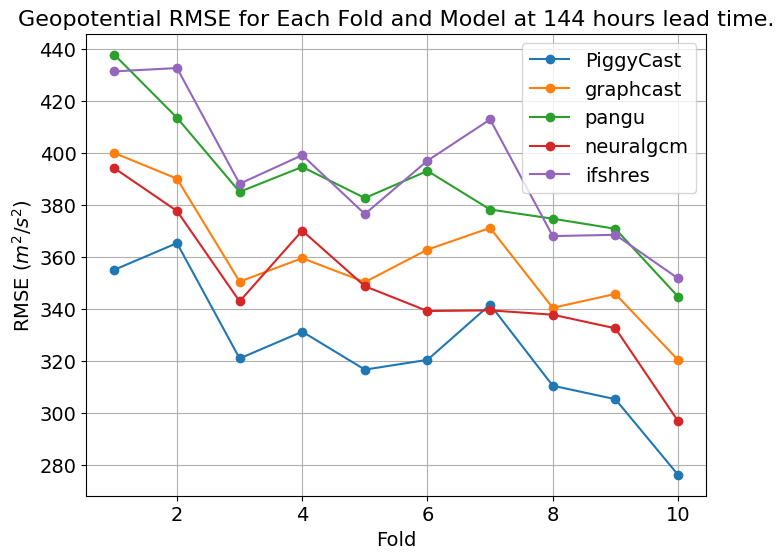

Lead time: 168
Shape of x :(1497088, 6)
Shape of y : (1497088,)


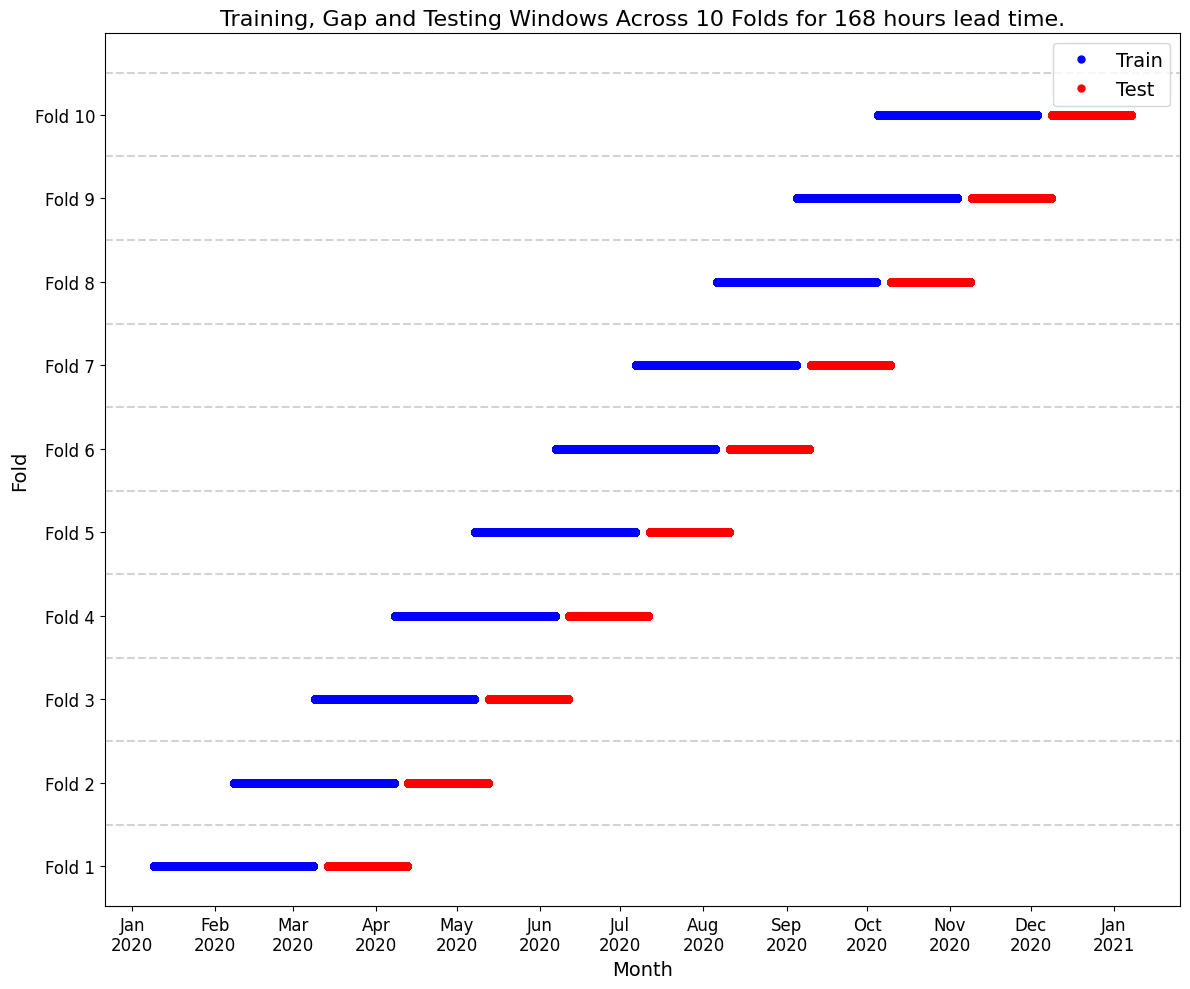

Fold 1:
  mse: 319447.1875
  PiggyCast: area weighted rmse: 465.55137009134086
  graphcast: area weighted rmse: 516.5422950305393
  pangu: area weighted rmse: 560.669637990778
  neuralgcm: area weighted rmse: 517.9174420535503
  ifshres: area weighted rmse: 561.0826418031471
Fold 2:
  mse: 435310.375
  PiggyCast: area weighted rmse: 474.9369979495044
  graphcast: area weighted rmse: 495.34725978935853
  pangu: area weighted rmse: 530.7699369814051
  neuralgcm: area weighted rmse: 487.7565948560344
  ifshres: area weighted rmse: 550.5007853279575
Fold 3:
  mse: 319079.4375
  PiggyCast: area weighted rmse: 426.7487698881755
  graphcast: area weighted rmse: 449.265769581539
  pangu: area weighted rmse: 490.7057771607287
  neuralgcm: area weighted rmse: 447.84205948644023
  ifshres: area weighted rmse: 501.9721934346873
Fold 4:
  mse: 300239.5625
  PiggyCast: area weighted rmse: 417.27245046657623
  graphcast: area weighted rmse: 455.23167573534784
  pangu: area weighted rmse: 494.78875392

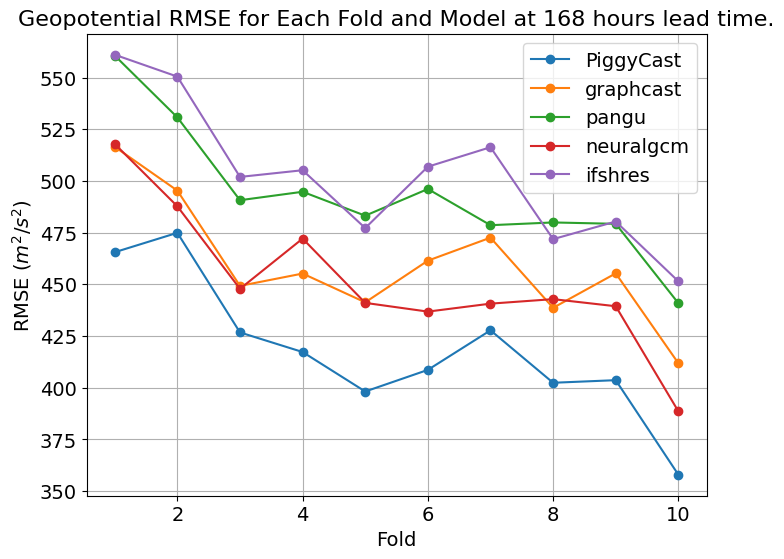

Lead time: 192
Shape of x :(1497088, 6)
Shape of y : (1497088,)


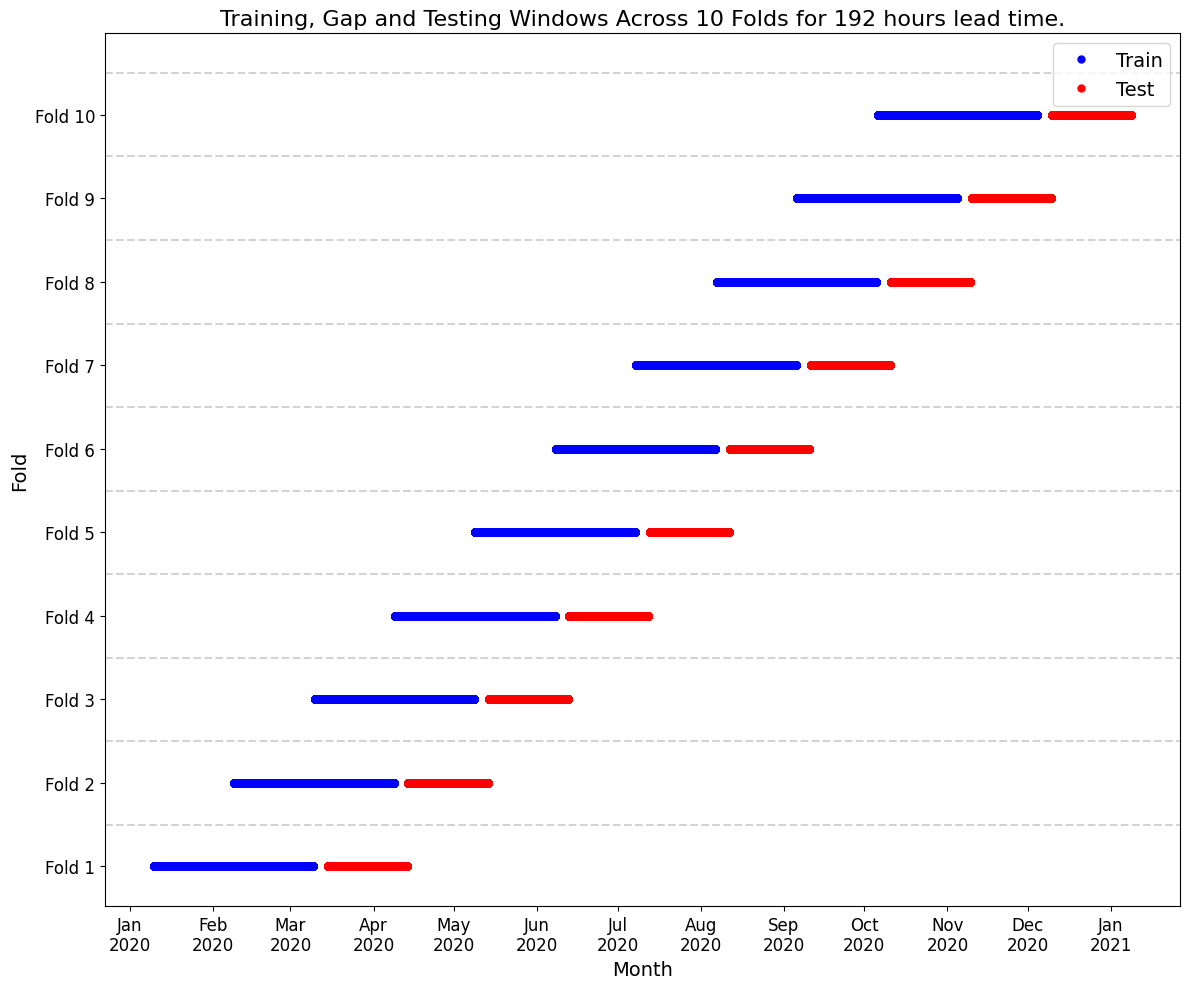

Fold 1:
  mse: 468353.625
  PiggyCast: area weighted rmse: 564.794973053611
  graphcast: area weighted rmse: 625.470275795337
  pangu: area weighted rmse: 680.7367166208414
  neuralgcm: area weighted rmse: 639.6101594398277
  ifshres: area weighted rmse: 679.2020545841017
Fold 2:
  mse: 569652.0625
  PiggyCast: area weighted rmse: 564.608124130367
  graphcast: area weighted rmse: 598.4659210454494
  pangu: area weighted rmse: 644.5994269484793
  neuralgcm: area weighted rmse: 594.1975327033562
  ifshres: area weighted rmse: 653.1504538479115
Fold 3:
  mse: 414059.0625
  PiggyCast: area weighted rmse: 507.04163582490537
  graphcast: area weighted rmse: 541.3736593137081
  pangu: area weighted rmse: 588.2541141473259
  neuralgcm: area weighted rmse: 543.1096423735861
  ifshres: area weighted rmse: 605.134067717397
Fold 4:
  mse: 422682.4375
  PiggyCast: area weighted rmse: 501.31573212705683
  graphcast: area weighted rmse: 551.6999301439422
  pangu: area weighted rmse: 587.0907149281459

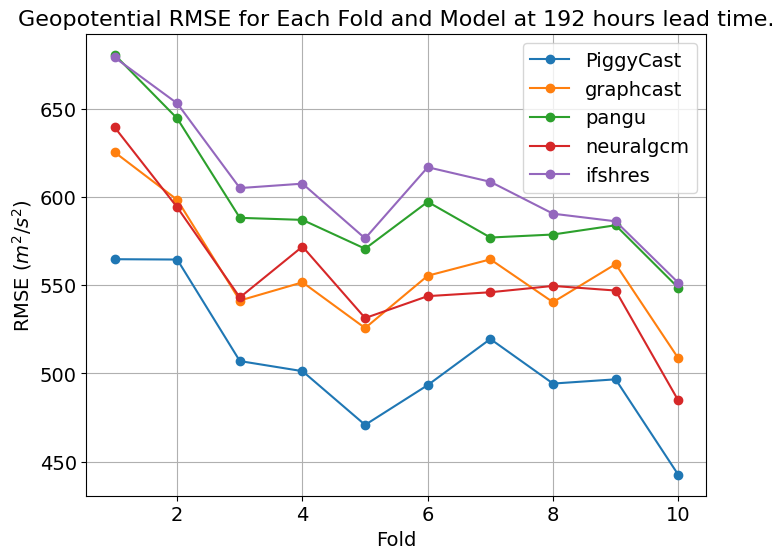

Lead time: 216
Shape of x :(1497088, 6)
Shape of y : (1497088,)


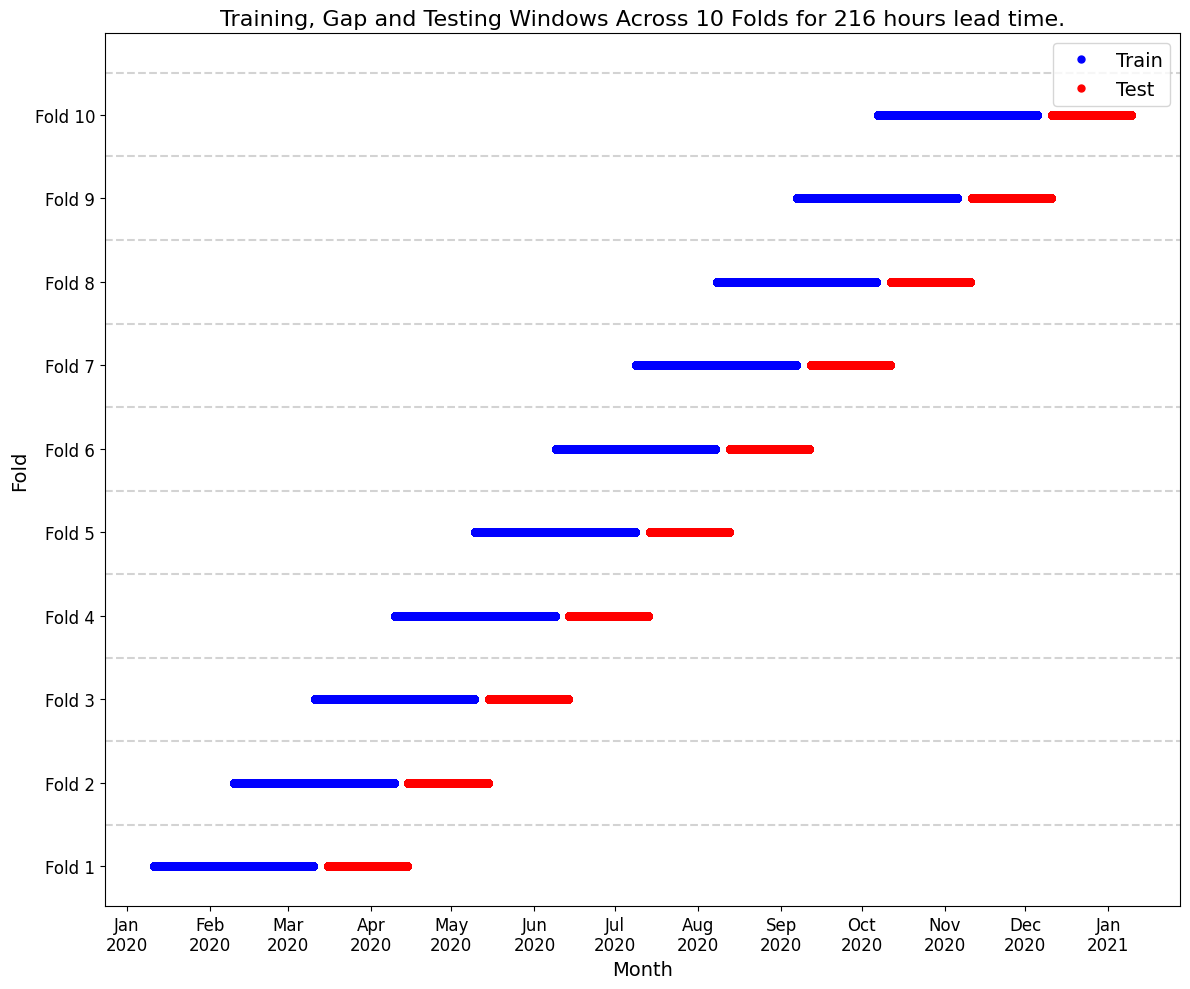

Fold 1:
  mse: 627538.25
  PiggyCast: area weighted rmse: 660.3042263674213
  graphcast: area weighted rmse: 726.5551677857665
  pangu: area weighted rmse: 786.261604528302
  neuralgcm: area weighted rmse: 751.3368408021788
  ifshres: area weighted rmse: 783.6516184664015
Fold 2:
  mse: 813364.375
  PiggyCast: area weighted rmse: 665.5241948973644
  graphcast: area weighted rmse: 698.0734547370295
  pangu: area weighted rmse: 746.7934322237379
  neuralgcm: area weighted rmse: 695.8812465286491
  ifshres: area weighted rmse: 749.4210496008965
Fold 3:
  mse: 575590.625
  PiggyCast: area weighted rmse: 586.6635337571969
  graphcast: area weighted rmse: 637.6189031398014
  pangu: area weighted rmse: 675.9223086595254
  neuralgcm: area weighted rmse: 616.9967084718618
  ifshres: area weighted rmse: 691.5701241098359
Fold 4:
  mse: 552877.3125
  PiggyCast: area weighted rmse: 571.8950391317316
  graphcast: area weighted rmse: 635.8148764231282
  pangu: area weighted rmse: 671.0675252541351
 

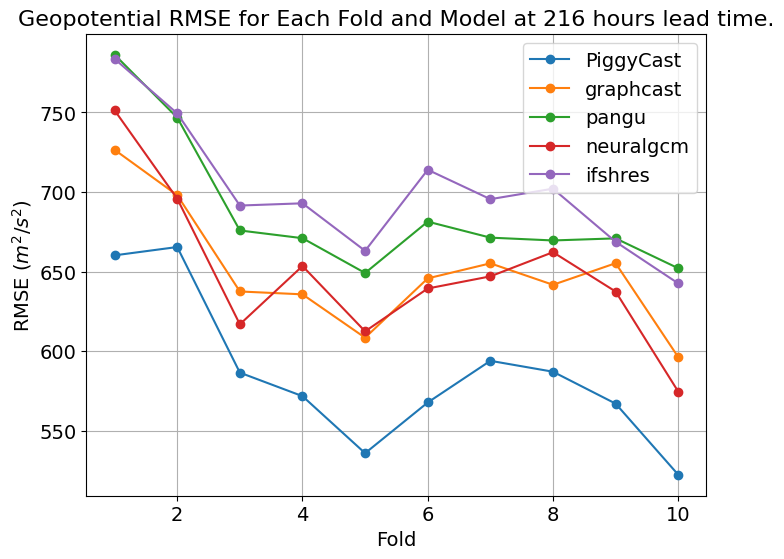

Lead time: 240
Shape of x :(1497088, 6)
Shape of y : (1497088,)


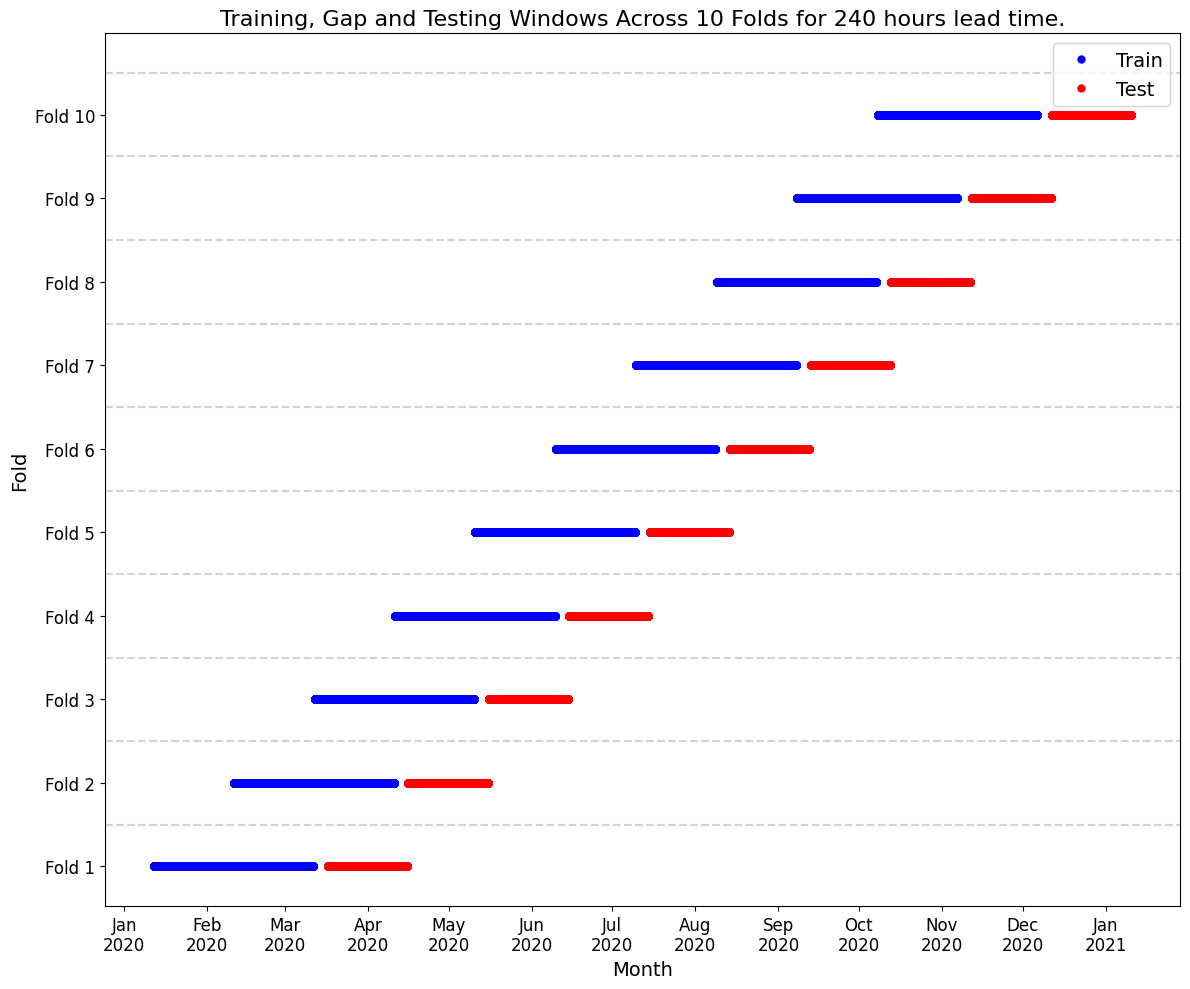

Fold 1:
  mse: 760803.625
  PiggyCast: area weighted rmse: 726.998061738262
  graphcast: area weighted rmse: 814.6594383141947
  pangu: area weighted rmse: 870.6131290660581
  neuralgcm: area weighted rmse: 846.950876925159
  ifshres: area weighted rmse: 875.7820567983599
Fold 2:
  mse: 984704.8125
  PiggyCast: area weighted rmse: 741.7549659335201
  graphcast: area weighted rmse: 779.195539101737
  pangu: area weighted rmse: 822.9137891295799
  neuralgcm: area weighted rmse: 782.0572208250487
  ifshres: area weighted rmse: 822.9747051042856
Fold 3:
  mse: 599431.5625
  PiggyCast: area weighted rmse: 641.6121603824067
  graphcast: area weighted rmse: 726.6376015880953
  pangu: area weighted rmse: 746.5197768039227
  neuralgcm: area weighted rmse: 686.1841503312471
  ifshres: area weighted rmse: 768.0081999689693
Fold 4:
  mse: 634814.9375
  PiggyCast: area weighted rmse: 618.7679861470245
  graphcast: area weighted rmse: 699.9222855824837
  pangu: area weighted rmse: 733.7635967872285


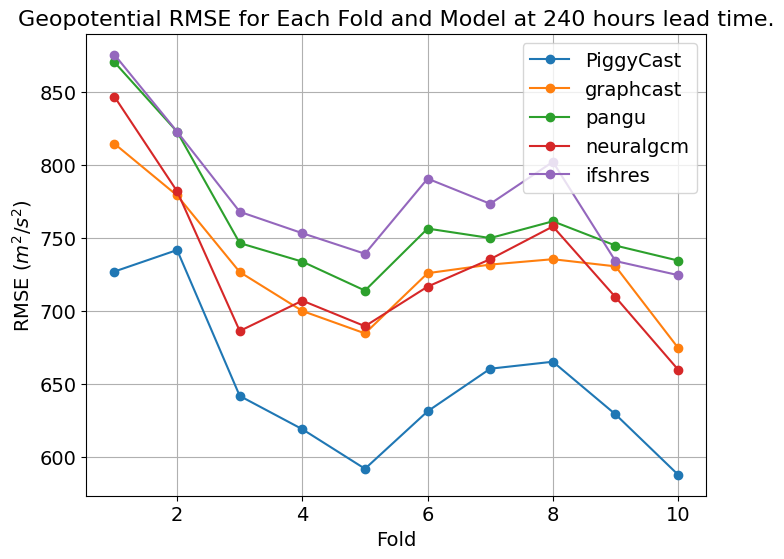

In [32]:
# Initialize xgb regressor
xgb = xgboost.XGBRegressor(random_state=42, device="cuda")

# Calculate Cross-Validation using 10 folds
cv_timeseries = TimeSeriesSplit(n_splits=10, max_train_size=32 * 64 * 2 * 60,
                                test_size= 32 * 64 * 2 * 30, gap=32 * 64 * 2 * 5)

# Lead Times
lead_times: list[int] = [24, 48, 72, 96, 120, 144, 168, 192, 216, 240]

# Nested scores for each lead time
nested_scores: dict = {}
# rmse results for each lead time, models
rmse_results: dict = {}
# Shapley values for each lead time
shapley_values_results: dict = {}

# Loop through each lead time to train and evaluate the model
for lead_time in lead_times:
    print(f"Lead time: {lead_time}")

    df_filtered: pd.DataFrame = data_per_lead_time(full_df,lead_time)

    X: pd.DataFrame = df_filtered[[f"graphcast_lt{lead_time}", f"pangu_lt{lead_time}",
                   f"neuralgcm_lt{lead_time}",
                   f"ifshres_lt{lead_time}", "longitude", "latitude"]]
    y: pd.Series = df_filtered["era5"]
    area_weight: pd.Series = df_filtered["area_weight"]

    print(f"Shape of x :{X.shape}")
    print(f"Shape of y : {y.shape}")

    # Nested Scores
    nested_score = cross_validate(xgb, X=X, y=y, cv=cv_timeseries,
                              scoring=('neg_mean_squared_error', 'r2'),
                              params={'sample_weight': area_weight}
                              )
    nested_scores[lead_time] = nested_score

    # Cross validation plot
    cross_validation_plot(df_filtered, cv_timeseries, lead_time)

    # RMSE and SHAPley Values
    rmse_result, shapley_values = train_and_evaluate(xgb, cv_timeseries,X,y, area_weight, lead_time)
    rmse_results[lead_time] = rmse_result
    shapley_values_results[lead_time]= shapley_values

    # RMSE plots per model
    rmse_per_fold_plot(rmse_result, lead_time)

In [33]:
# ================================================================
# @title 🌱 Stop emissions tracking and report
# ================================================================
emissions = emissions_tracker.stop()

print("\n" + "="*55)
print("🌱 PiggyCast Training — Energy & Emissions Report")
print("="*55)
print(f"  Estimated CO₂ equivalent: {emissions*1000:.4f} gCO₂eq")
print(f"  (Full report saved to: emissions.csv)")
print("\nContext:")
print("  • Average car trip (1 km): ~120 gCO₂eq")
print("  • Streaming 1 hr of video: ~36 gCO₂eq")
print("  • Sending 1 email:          ~4 gCO₂eq")
print("\nℹ️  This demonstrates that a single tutorial training run")
print("   has a relatively small carbon footprint. However, at scale")
print("   (repeated retraining, hyperparameter search, large models),")
print("   these costs add up — tracking them is good practice.")



🌱 PiggyCast Training — Energy & Emissions Report
  Estimated CO₂ equivalent: 2.3888 gCO₂eq
  (Full report saved to: emissions.csv)

Context:
  • Average car trip (1 km): ~120 gCO₂eq
  • Streaming 1 hr of video: ~36 gCO₂eq
  • Sending 1 email:          ~4 gCO₂eq

ℹ️  This demonstrates that a single tutorial training run
   has a relatively small carbon footprint. However, at scale
   (repeated retraining, hyperparameter search, large models),
   these costs add up — tracking them is good practice.


---
## 🧪 Interactive Exercise 1: Effect of XGBoost Hyperparameters

The XGBoost model above uses default hyperparameters. Try modifying the parameters below and re-run the training loop to observe how they affect PiggyCast's RMSE.

**Instructions:**
1. In the training cell above, change `n_estimators` from `100` to `200` or `50`.
2. Change `max_depth` from `6` to `3` or `9`.
3. Note how average RMSE at 48 h and 240 h changes.

**Questions to consider:**
- Does increasing `n_estimators` always improve performance? At what cost?
- What effect does `max_depth` have on overfitting vs. underfitting?
- Which lead time is most sensitive to hyperparameter changes?

> 💡 **Tip:** You can use `xgb_model.get_params()` after fitting to confirm the parameters used.


## PiggyCast Results



### PiggyCast's Evaluation: Area-Weighted RMSE

The models are evaluated per fold using the area-weighted RMSE for fair temporal grid area weighting. This weighted RMSE per fold and model for a 48-hour lead time is shown above. Here, PiggyCast's performance is poor compared to the other models, specifically NeuralGCM.
On average (across folds), NeuralGCM performs better with $\mathbf{60.76}~ m^2/s^2$ RMSE than all the other models, followed by PiggyCast ($\mathbf{64.18}~ m^2/s^2$), GraphCast ($\mathbf{69.64}~ m^2/s^2$), IFS HRES ($\mathbf{74.19}~ m^2/s^2$) and finally Pangu ($\mathbf{75.76}~ m^2/s^2$) on this short lead time.

At a 72-hour lead time, PiggyCast performance is noted to improve and provides the best predictions compared to the other models. It is only at fold one where NeuralGCM is better than PiggyCast, while at fold four, NeuralGCM matches the performance of PiggyCast. On average (across folds), PiggyCast's RMSE leads with $\mathbf{101.99}~ m^2/s^2$, followed by NeuralGCM ($\mathbf{105.11}~ m^2/s^2$), GraphCast ($\mathbf{115.48}~ m^2/s^2$), IFS HRES ($\mathbf{124.99}~ m^2/s^2$) and finally Pangu ($\mathbf{125.84}~ m^2/s^2$).

Similarly, PiggyCast's performance continues to dominate the other models until the last 240-hour lead time. On average (across folds), PiggyCast's RMSE leads with $\mathbf{649.38}~ m^2/s^2$, followed by NeuralGCM ($\mathbf{729.08}~ m^2/s^2$), GraphCast ($\mathbf{730.32}~ m^2/s^2$), Pangu ($\mathbf{763.50}~ m^2/s^2$) and finally IFS HRES ($\mathbf{778.44}~ m^2/s^2$).

To evaluate the models' performance across 24-240 lead times, we calculate and plot the average RMSE across folds for each model per time lead as shown in the figure below.

PiggyCast's dominance is observed as the lead time increases. NeuralGCM starts better but converges with GraphCast from 192-240 hours lead times. Similarly, IFS HRES and Pangu performance are similar but distinguishable from 120-240 hours lead times.


In [34]:
# @title Calculate Average RMSE of Model per Lead time

# This section calculates the mean RMSE for each model across all folds for each lead time.

def rmse_mean_per_lead_time_and_model(rmse_results: dict) -> dict:
  """
  Calculates the mean RMSE for each model across all folds for each lead time.

  Args:
      rmse_results: A dictionary containing RMSE values for each model and fold,
                    structured as {lead_time: {fold: {model: rmse}}}.

  Returns:
      A dictionary containing the average RMSE for each model per lead time,
      structured as {lead_time: {model: average_rmse}}.
  """
  # average scores per lead time and model
  average_scores = {}

  for lead_time, folds in rmse_results.items():
      model_scores = defaultdict(list)

      # collect values per model
      for fold_scores in folds.values():
          for model, value in fold_scores.items():
              model_scores[model].append(value)

      # average for each model
      average_scores[lead_time] = {model: float(np.mean(scores)) for model, scores in model_scores.items()}
  return average_scores

In [35]:
# @title Average RMSE Scores per model per lead time

# This section prints the average RMSE scores for each model across all lead times.
# print nicely

average_scores: dict = rmse_mean_per_lead_time_and_model(rmse_results)
pprint(average_scores)

{24: {'PiggyCast': 45.1903671197331,
      'graphcast': 40.45263015679894,
      'ifshres': 41.345575813764434,
      'neuralgcm': 32.75108103284507,
      'pangu': 42.71260853724858},
 48: {'PiggyCast': 64.1775584914425,
      'graphcast': 69.63800331707469,
      'ifshres': 74.18631782545808,
      'neuralgcm': 60.76147382469113,
      'pangu': 75.75723848328518},
 72: {'PiggyCast': 101.99432560939412,
      'graphcast': 115.48760779732575,
      'ifshres': 124.99237446580557,
      'neuralgcm': 105.10781897069894,
      'pangu': 125.83565063238966},
 96: {'PiggyCast': 159.17793967232666,
      'graphcast': 179.66465739456424,
      'ifshres': 197.23465344920965,
      'neuralgcm': 169.5452751589802,
      'pangu': 196.21785805711082},
 120: {'PiggyCast': 235.87207436116574,
       'graphcast': 263.02001145458746,
       'ifshres': 288.772845868478,
       'neuralgcm': 252.5258417125255,
       'pangu': 285.7960725176161},
 144: {'PiggyCast': 324.301274983238,
       'graphcast': 359

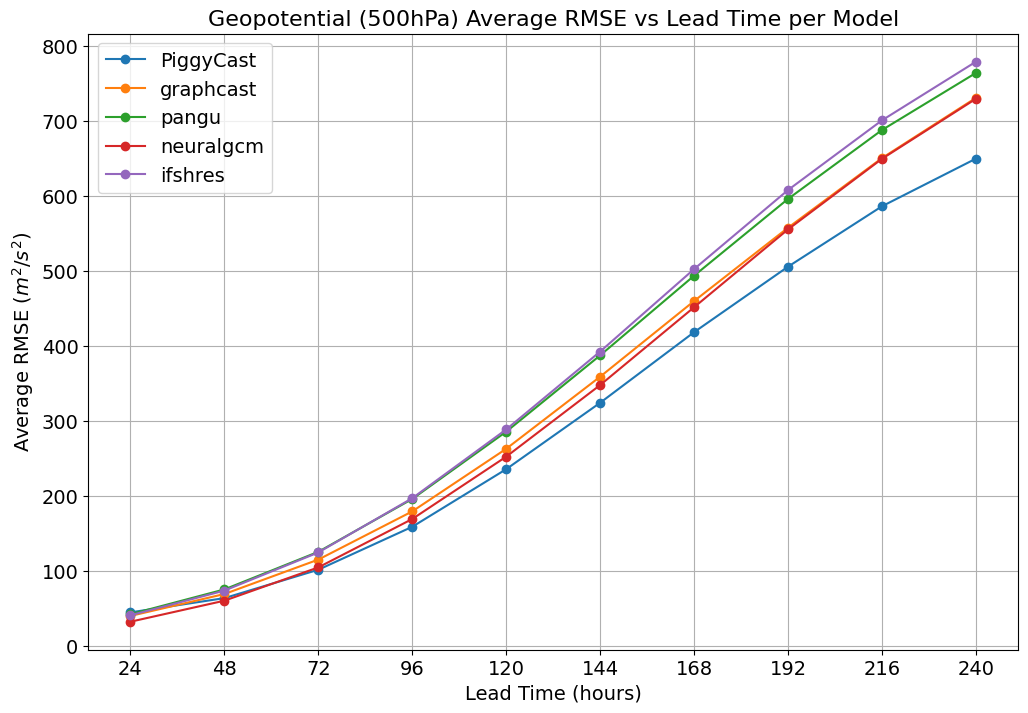

In [36]:
# @title Plot RMSE per lead time and Model

# This section plots the average RMSE for each model across all lead times.
def rmse_per_lead_time_plot_all_lead_times(average_scores: dict):
  """
  Plots the average RMSE for each model across all lead times.

  Args:
      average_scores: A dictionary containing the average RMSE for each model
                      per lead time, structured as {lead_time: {model: average_rmse}}.
  """
  models = list(average_scores[next(iter(average_scores))].keys())

  fig, ax = plt.subplots(figsize=(12, 8))

  for model in models:
      avg_rmse_per_lead_time = []
      lead_times = []

      for lead_time, lead_time_average in average_scores.items():
          avg_rmse_per_lead_time.append(lead_time_average[model])
          lead_times.append(lead_time)

      ax.plot(lead_times, avg_rmse_per_lead_time, label=model, marker='o')

  ax.set_xlabel("Lead Time (hours)")
  ax.set_ylabel("Average RMSE ($ m^2/s^2$)")
  ax.set_title("Geopotential (500hPa) Average RMSE vs Lead Time per Model")
  ax.set_xticks(range(min(lead_times), max(lead_times)+1, 24))  # Set interval of 24 hours
  ax.legend(loc="upper left")
  plt.rcParams['axes.titlesize'] = 16
  plt.rcParams['axes.labelsize'] = 14
  plt.rcParams['xtick.labelsize'] = 14
  plt.rcParams['ytick.labelsize'] = 14
  plt.rcParams['legend.fontsize'] = 14
  plt.grid(True)
  plt.savefig(drive_plots_path + 'Average_RMSE_vs_Lead_Time_per_Model.pdf', dpi=300, bbox_inches="tight")
  plt.show()

rmse_per_lead_time_plot_all_lead_times(average_scores)

In [37]:
# ================================================================
# @title 🌡️ Climatology RMSE per Lead Time
# ================================================================

# def clim_rmse_for_leadtime(df_lt, lead_hours, clim_df):
#     """
#     Compute area-weighted RMSE of the climatology baseline.

#     Parameters
#     ----------
#     df_lt      : pd.DataFrame — must have columns [era5, latitude,
#                  longitude, area_weight, time] where 'time' is the
#                  initialisation time.
#     lead_hours : int — forecast lead time (e.g. 48, 72, ...).
#     clim_df    : pd.DataFrame — loaded climatology with columns
#                  [era5_clim_m, hour, dayofyear, latitude, longitude].
#     """
#     df = df_lt.copy()
#     df["valid_time"] = pd.to_datetime(df["time"]) + pd.Timedelta(hours=lead_hours)
#     df["dayofyear"]  = df["valid_time"].dt.day_of_year
#     df["hour"]       = df["valid_time"].dt.hour   # 0 or 12 for 12-h data

#     merged = df.merge(
#         clim_df[["dayofyear", "hour", "latitude", "longitude", "era5_clim_m"]],
#         on=["dayofyear", "hour", "latitude", "longitude"],
#         how="left",
#     )

#     n_missing = merged["era5_clim_m"].isna().sum()
#     if n_missing > 0:
#         print(f"  ⚠️  Lead {lead_hours:3d}h: {n_missing} rows unmatched — "
#               f"check longitude range alignment between forecast and climatology DataFrames.")

#     rmse = np.sqrt(
#         (merged["area_weight"] * (merged["era5"] - merged["era5_clim_m"]) ** 2).sum()
#         / merged["area_weight"].sum()
#     )
#     return rmse

def clim_rmse(era5_clim_df):
    """
    Compute area-weighted RMSE of the climatology baseline.

    Parameters
    ----------
    era5_clim_df : merged DataFrame of era5 and era5_clim.
    """

    rmse = np.sqrt(
        (era5_clim_df["area_weight"] * (era5_clim_df["era5"] - era5_clim_df["era5_clim"]) ** 2).sum()
        / era5_clim_df["area_weight"].sum()
    )
    return rmse



In [38]:
lead_times_list = [24, 48, 72, 96, 120, 144, 168, 192, 216, 240]
clim_rmse_scores = {}

show_message("Computing climatology baseline RMSE across all lead times…")
for lt in lead_times_list:
    clim_rmse_scores[lt] = clim_rmse(era5_dataset_with_clim)
    print(f"  Lead {lt:3d} h → Climatology RMSE: {clim_rmse_scores[lt]:.2f} m")

show_message("✅ Climatology baseline ready.", color="green")

  Lead  24 h → Climatology RMSE: 801.27 m
  Lead  48 h → Climatology RMSE: 801.27 m
  Lead  72 h → Climatology RMSE: 801.27 m
  Lead  96 h → Climatology RMSE: 801.27 m
  Lead 120 h → Climatology RMSE: 801.27 m
  Lead 144 h → Climatology RMSE: 801.27 m
  Lead 168 h → Climatology RMSE: 801.27 m
  Lead 192 h → Climatology RMSE: 801.27 m
  Lead 216 h → Climatology RMSE: 801.27 m
  Lead 240 h → Climatology RMSE: 801.27 m


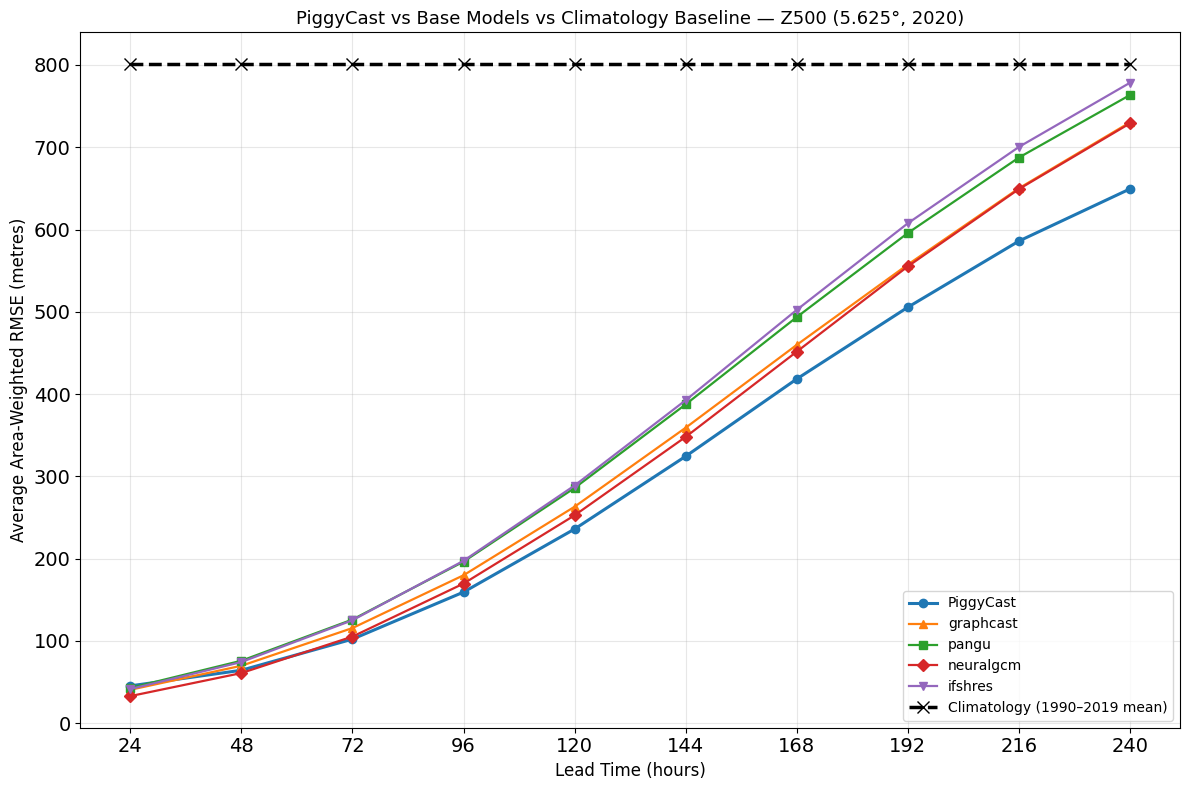

In [39]:
# ================================================================
# @title 🌡️ Plot All Models + Climatology Baseline
# ================================================================
# A model only has genuine forecast skill if it beats the climatology
# baseline. If any model's RMSE line rises above the dashed black line,
# it offers no improvement over predicting the long-run seasonal average.

fig, ax = plt.subplots(figsize=(12, 8))

model_styles = {
    "PiggyCast" : dict(color="tab:blue",   marker="o",  linewidth=2.2),
    "graphcast"  : dict(color="tab:orange", marker="^",  linewidth=1.6),
    "pangu"      : dict(color="tab:green",  marker="s",  linewidth=1.6),
    "neuralgcm"  : dict(color="tab:red",    marker="D",  linewidth=1.6),
    "ifshres"    : dict(color="tab:purple", marker="v",  linewidth=1.6),
}

# rmse_avg_all: {lead_time: {model_name: avg_rmse}} — built in the training loop
for display_name, style in model_styles.items():
    rmse_vals = [average_scores[lt][display_name] for lt in lead_times_list]
    ax.plot(lead_times_list, rmse_vals, label=display_name, **style)

ax.plot(
    lead_times_list,
    [clim_rmse_scores[lt] for lt in lead_times_list],
    color="black", linestyle="--", linewidth=2.5,
    marker="x", markersize=9,
    label="Climatology (1990–2019 mean)",
)

ax.set_xlabel("Lead Time (hours)", fontsize=12)
ax.set_ylabel("Average Area-Weighted RMSE (metres)", fontsize=12)
ax.set_title("PiggyCast vs Base Models vs Climatology Baseline — Z500 (5.625°, 2020)",
             fontsize=13)
ax.set_xticks(range(min(lead_times), max(lead_times)+1, 24))  # Set interval of 24 hours
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 🧪 Interactive Exercise 3: Climatology Baseline Interpretation

Now that you can see the climatology line on the plot above, answer the following questions:

1. **Skill check:** Do all base models beat the climatology baseline at every lead time? At which lead times (if any) does forecast skill start to approach the "no-skill" line?

2. **PiggyCast vs climatology:** By how many metres does PiggyCast's RMSE beat climatology at 240 hours? Is this margin large or small relative to the gap between models?

> 💡 **Key takeaway:** Beating climatology is a *necessary* condition for forecast skill. All models here do beat it — confirming they learn genuine atmospheric dynamics. But the margin narrows at longer lead times, illustrating the practical limit of deterministic predictability.


## PiggyCast Feature Attribution using SHAPley (SHAP) values

We attempt to gain insight into PiggyCast's decision-making process and explain the contribution of features of the model by using SHAPley (SHAP) values. SHAP values help attribute the marginal contribution of every feature towards the prediction at local and global levels.

Lead_time: 24 


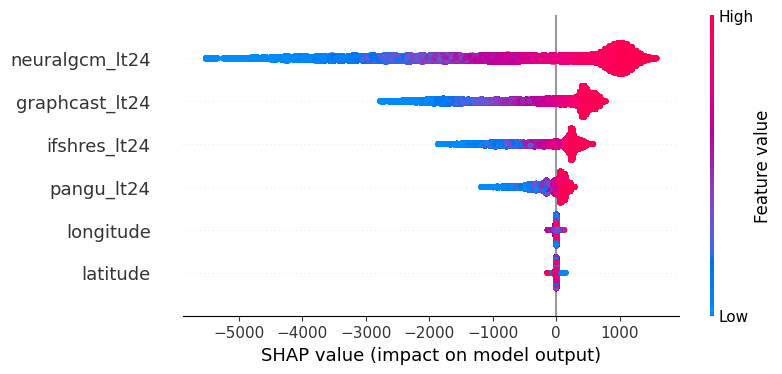

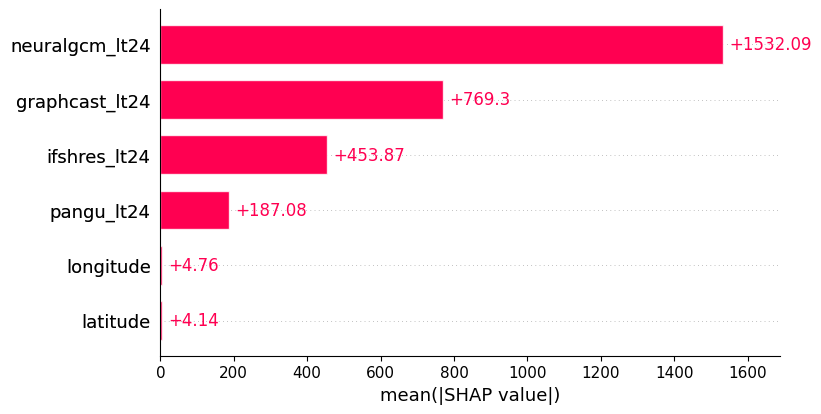

Lead_time: 48 


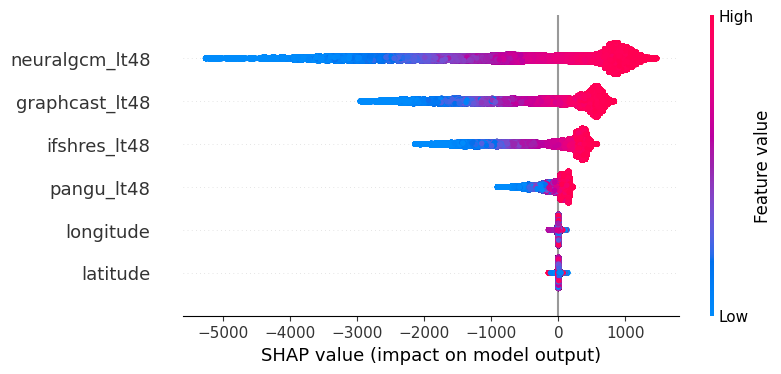

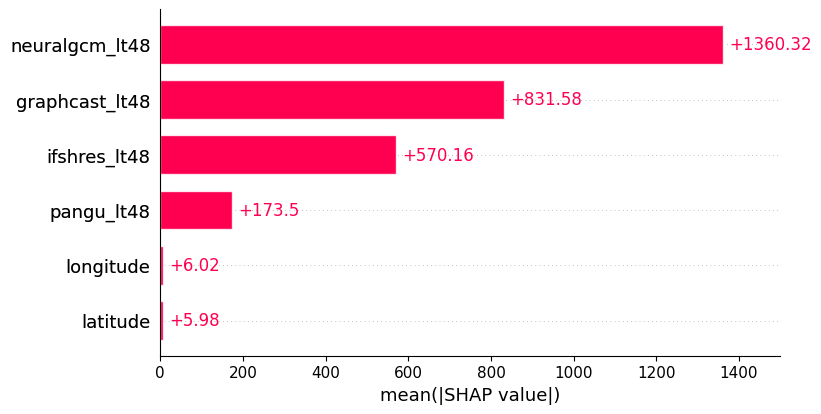

Lead_time: 72 


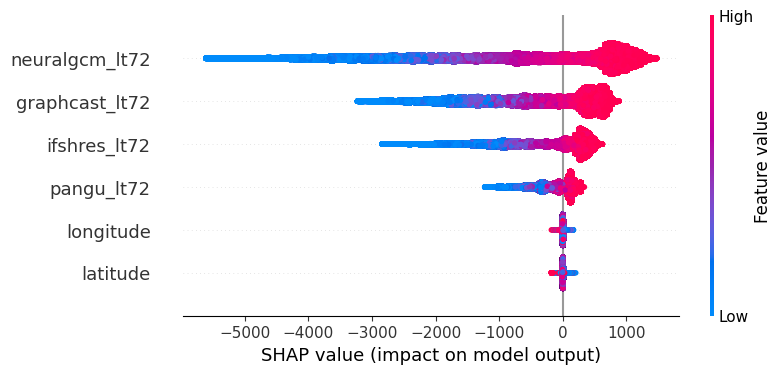

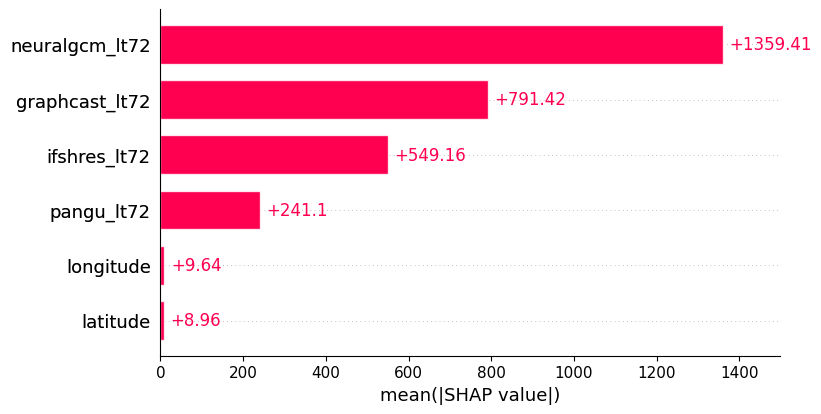

Lead_time: 96 


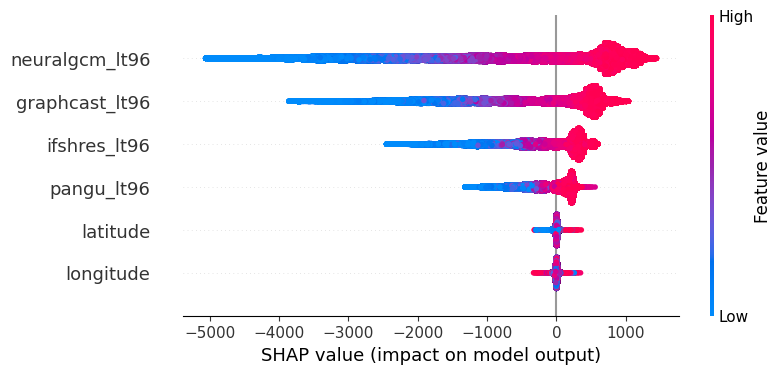

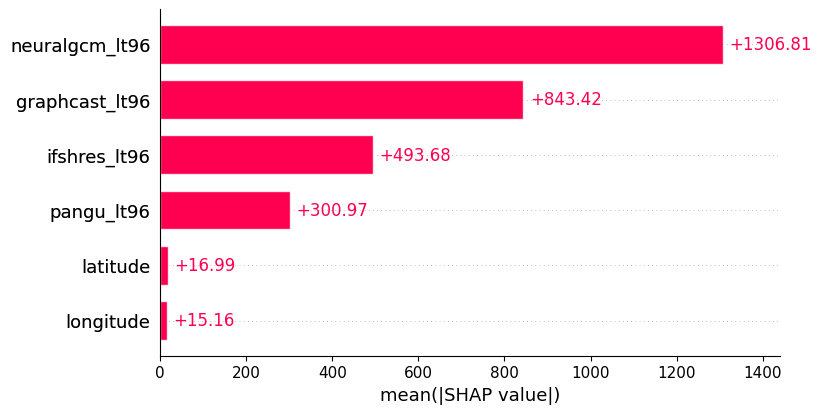

Lead_time: 120 


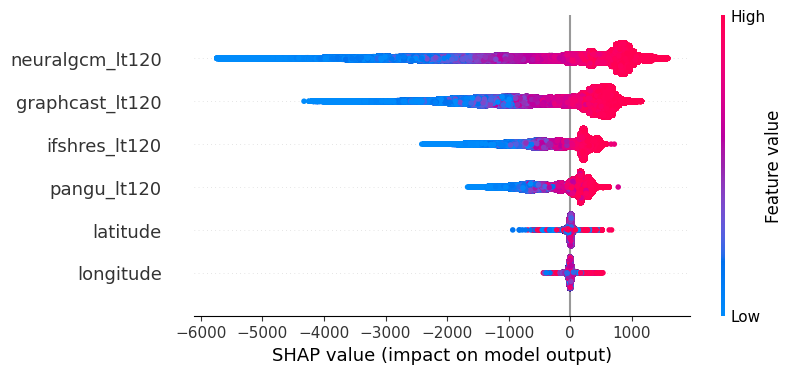

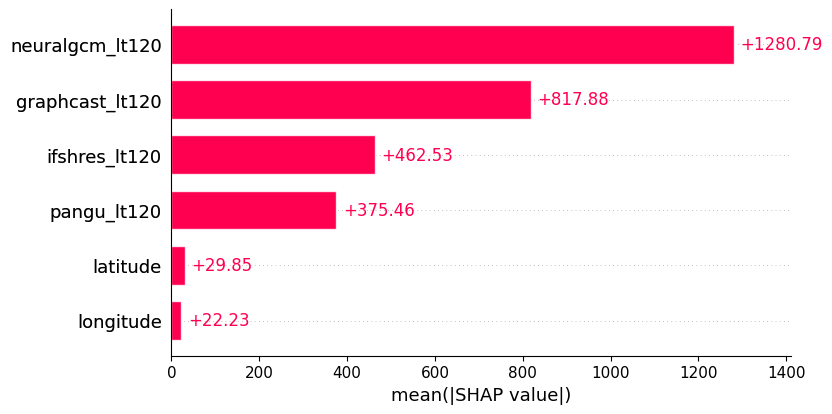

Lead_time: 144 


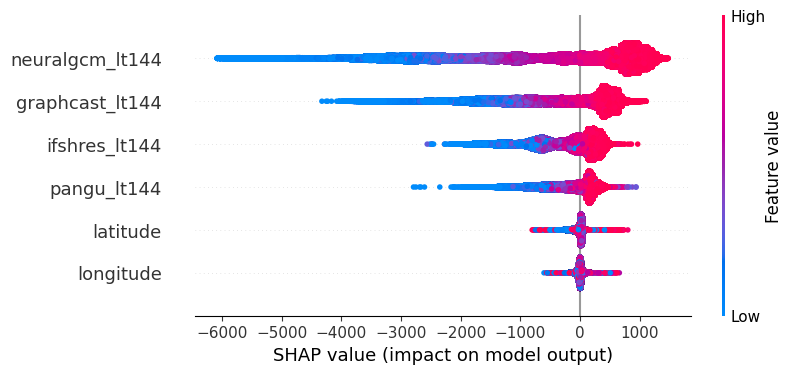

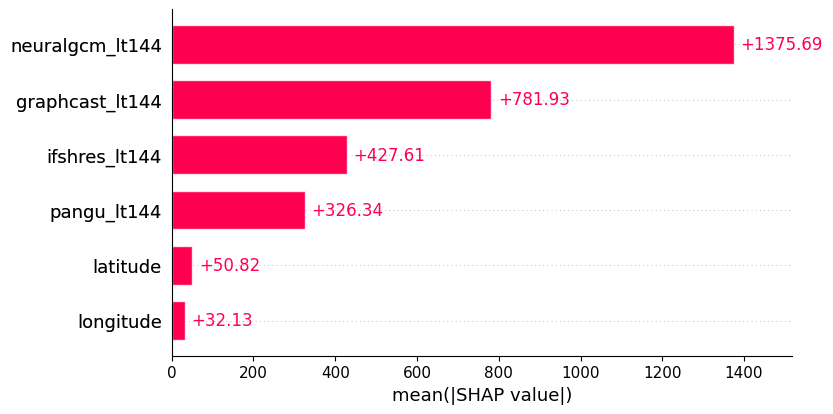

Lead_time: 168 


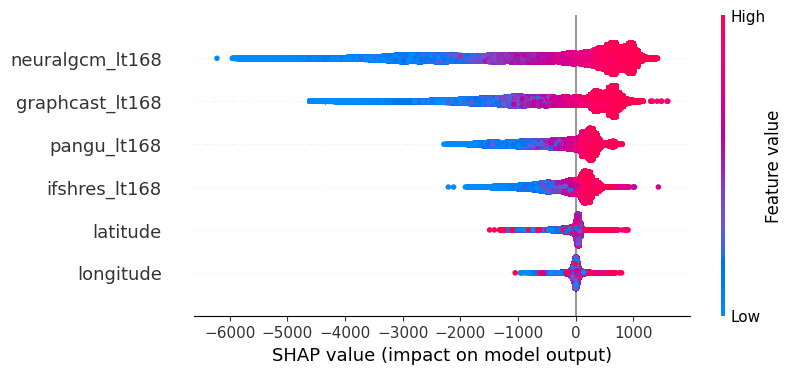

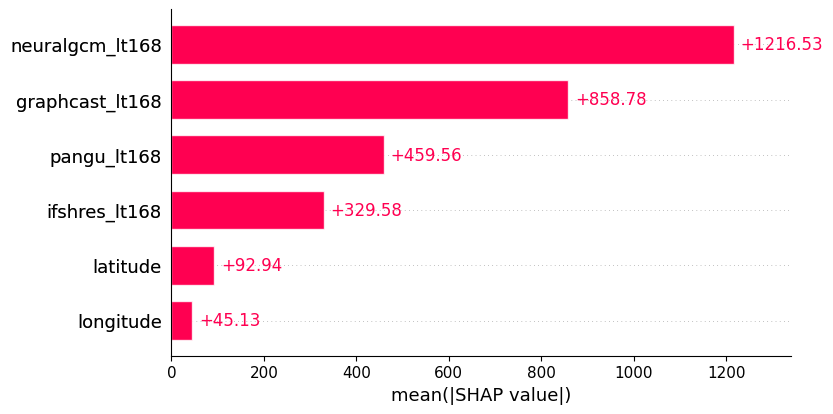

Lead_time: 192 


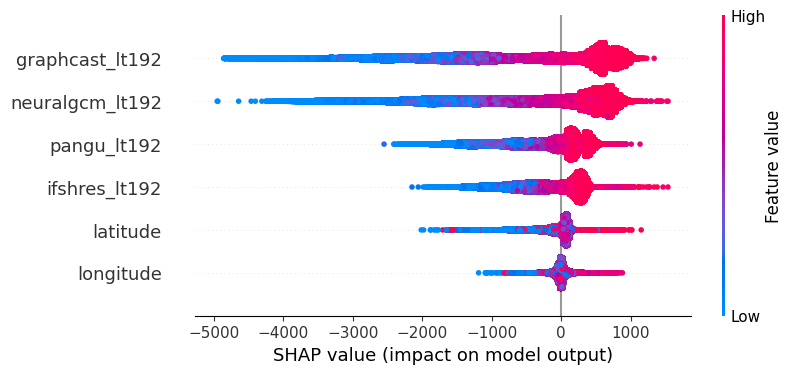

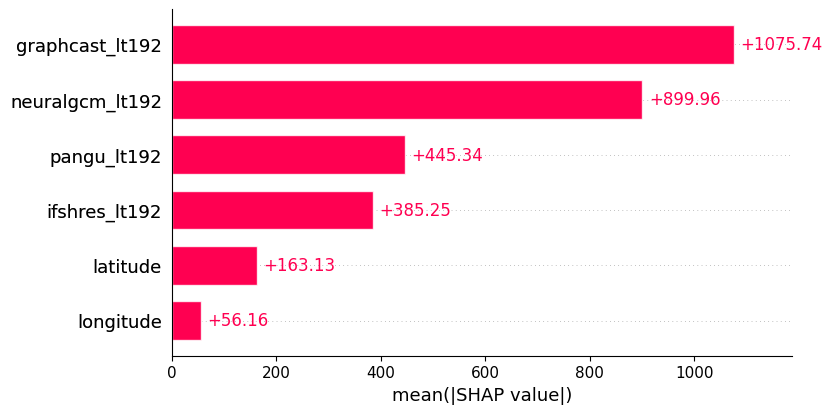

Lead_time: 216 


In [ ]:
# @title Plot Shapley Values for each lead time

# This section plots the Shapley values for each lead time using beeswarm and bar plots.
# Loop through each lead time to generate and plot SHAP values
for lead_time, shapley_explanations in shapley_values_results.items():
  print(f"Lead_time: {lead_time} ")
  combined_explanation = combined_shap_explanations_per_lead_time(shapley_explanations)
  shap.plots.beeswarm(combined_explanation)
  shap.plots.bar(combined_explanation, max_display=12)

At 72-hour lead time, the beeswarm figure below visualises the local contribution of each feature by either decreasing (negative SHAP values in blue) or increasing (positive SHAP values in red) the base value of each prediction. From the beeswarm plot, we observe that NeuralGCM, GraphCast and IFS HRES greatly influence PiggyCast's decision making at each prediction as seen with long and densely populated tails on either side of the zero divide. Pangu, longitude and latitude contribute the least to the prediction of the model, as seen with the short tails that are centred at zero.

For global feature contribution to PiggyCast's prediction, the corresponding bar plot helps ascertain the overall global contribution of each feature by using the mean absolute SHAP values at 72-hour lead time. From this bar plot, NeuralGCM leads with $\mathbf{1441.26}$ followed by GraphCast $\mathbf{959.16}$, IFS HRES $\mathbf{563.75}$, Pangu $\mathbf{221.79}$, longitude $\mathbf{7.88}$ and latitude $\mathbf{7.81}$.


Additionally, it is only at a 192-hour lead time do we notice GraphCast outcompete NeuralGCM in marginal contribution with a mean absolute SHAPley value of $\mathbf{1075.74}$ while NeuralGCM with $\mathbf{899.96}$. The contribution of spatial features (latitude and longitude) increases with the increase in lead time, with latitude contributing more than longitude.

<a name="model-card"></a>
# Model Card for PiggyCast

Model Cards ([Mitchell et al., 2019](https://arxiv.org/abs/1810.03993)) document the intended use, performance, and limitations of ML models to support responsible deployment. Below is a model card for PiggyCast as implemented in this tutorial.

---

## Model Details

| Field | Value |
|---|---|
| **Model name** | PiggyCast v2.0 (CCAI Summer School 2026) |
| **Model type** | XGBoost stacking ensemble regressor |
| **Version** | 2.0 |
| **Authors** | Josiah K. Kimani, Oliver Angélil, Chris Fotso, Steffen Knoblauch |
| **License** | MIT |
| **Contact** | josiah@aims.ac.za |

**Architecture:** An XGBoost gradient-boosted decision tree trained to map the concatenated outputs of four base forecasting models (GraphCast, Pangu-Weather, NeuralGCM, IFS HRES) plus geographic coordinates (lat/lon) to ERA5 reanalysis values. A separate model is trained per lead time (9 in total).

---

## Intended Use

- **Primary use:** Research and educational demonstration of ensemble stacking for weather forecasting post-processing.
- **Intended users:** Researchers, students, and practitioners in AI and climate science.
- **Out-of-scope uses:**
  - Operational weather forecasting without additional validation, uncertainty quantification, and near-real-time data pipelines.
  - Forecasting variables other than Z500 without retraining.
  - Climate projection or trend analysis.

---

## Factors

- **Relevant factors:** Geographic region, forecast lead time, season, year. PiggyCast is trained and evaluated on global 2020 data; performance may differ by region, lead time, and under conditions not well-represented in the training year.
- **Evaluation factors:** The model is evaluated globally using area-weighted RMSE. Regional skill varies — results over data-sparse regions (polar areas, Africa) may be less reliable.

---

## Metrics

| Metric | Description |
|---|---|
| Area-weighted RMSE (m) | Root mean squared error of Z500 prediction, weighted by cos(latitude) to correct for grid over-representation at poles |

**PiggyCast outperforms all base models at lead times ≥ 120 h.** At 48 h, NeuralGCM achieves lower RMSE (60.76 m vs. PiggyCast's 64.18 m), but the gap narrows and reverses at longer horizons.

---

## Evaluation Data

- **Dataset:** ERA5 Z500, WeatherBench 2 archive, year 2020, 5.625° resolution
- **Split strategy:** Rolling time-series cross-validation (10 folds, `TimeSeriesSplit` with gap). No data from after the training window is used during training.
- **Known biases:** Single-year evaluation may not capture inter-annual variability. Performance on extreme events (e.g., blocking highs, sudden stratospheric warmings) is not specifically evaluated.

---

## Ethical Considerations

- **Downstream decisions:** Improved weather forecasts can influence evacuation orders, agricultural decisions, and energy dispatch. Errors carry real-world consequences — this model should not be used to directly inform high-stakes decisions without operational validation.
- **Equity:** Forecast skill depends on data availability. ERA5 reanalysis quality is lower over data-sparse regions such as sub-Saharan Africa, meaning benefits of improved prediction may be unequally distributed.
- **Energy cost:** Training this tutorial model on a T4 GPU takes ~4 minutes. The energy and CO2 emissions are tracked using CodeCarbon (see results above). At scale, repeated retraining of ensemble models should be weighed against forecast skill gains.
- **Transparency:** All training data, code, and model artifacts for this tutorial are publicly available.

---

## Caveats & Recommendations

- PiggyCast's advantage grows with lead time — it is most useful for 5–10 day forecasting.
- Retraining is required when base model versions change (e.g., GraphCast updates).
- Probabilistic extensions (e.g., quantile regression, conformal prediction) are needed before operational use.
- Validation on additional years and variables is strongly recommended before drawing broad conclusions.


<a name="limitations"></a>
# Limitations & Future Works

The findings of this tutorial highlight the value of integrating diverse modelling paradigms and employing advanced machine learning techniques for weather prediction.

Specifically we set out to:
  * Develop and assess an ensemble machine learning model through stacking forecasts from numerical, AI-based and hybrid weather prediction models for enhanced predictive performance.
  * Investigate the effect of input features on the trained ensemble model for interpretability and explainability of the forecasting process.

While this tutorial demonstrates the potential of the PiggyCast ensemble framework for medium-range weather forecasting, several important avenues remain open for further development and exploration:

* Expanded Evaluation Metrics:

Current evaluation relies primarily on RMSE. Incorporating additional skill scores such as anomaly correlation, bias, and spatial pattern correlations across lead times and regions would provide a more complete view of model performance and help interpret where PiggyCast excels or struggles.


* Model Behaviour and Error Analysis:

A deeper investigation into the underperformance of PiggyCast compared to NeuralGCM, especially in earlier lead times, could reveal systematic biases or ensemble-weighting inefficiencies. Sensitivity analyses over spatial domains may also explain regional variations in skill.

* Probabilistic and Uncertainty-Aware Forecasting:

Although this tutorial focuses on deterministic forecasts, real-world climate decision-making often depends on uncertainty quantification. Extending PiggyCast to a probabilistic ensemble; for example, through Bayesian averaging or ensemble spread estimation, would enhance its reliability and practical relevance.

---

**🔎 Reflection question:** *What would a probabilistic version of PiggyCast look like? How might you modify the XGBoost objective or output to produce prediction intervals?*

---

* Additional Variables and Extremes:

Incorporating more atmospheric variables and extending the framework to extreme weather events or nonstationary climate conditions could test PiggyCast’s adaptability and improve its value for climate adaptation and disaster preparedness.

> These limitations do not diminish the tutorial's scientific value — they frame it correctly as a research prototype.

<a name="references"></a>
# References

* Lorenz, 1963 : https://cdanfort.w3.uvm.edu/research/lorenz-1963.pdf$0
* XGBoost Paper: https://arxiv.org/abs/1603.02754
* WeatherBench2 AI-Weather SotA vs Time evaluation: https://docs.google.com/spreadsheets/d/1n30zDDjEzlXl5nAGF8uD_dbZWJAamqImQGCZjfOMuDg/edit?gid=0#gid=0
* WeatherBench2 Deterministic Scores: https://sites.research.google/weatherbench/deterministic-scores/
* NeuralGCM paper: https://www.nature.com/articles/s41586-024-07744-y
* GraphCast paper: https://arxiv.org/abs/2212.12794
* Pangu-Weather paper: https://arxiv.org/abs/2211.02556
* IFS Hres : https://www.ecmwf.int/en/about/media-centre/focus/2024/plans-high-resolution-forecast-hres-and-ensemble-forecast-ens#:~:text=With%20the%20upgrade%20of%20the,with%20the%20agreed%20dissemination%20schedule.
* Zarr format : https://journals.ametsoc.org/view/journals/atot/39/4/JTECH-D-21-0106.1.pdf

